C:\Users\freed\AppData\Local\Temp\ipykernel_23200\2110163118.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.tight_layout()
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.tight_layout()
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  fig.tight_layout()
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  fig.tight_l

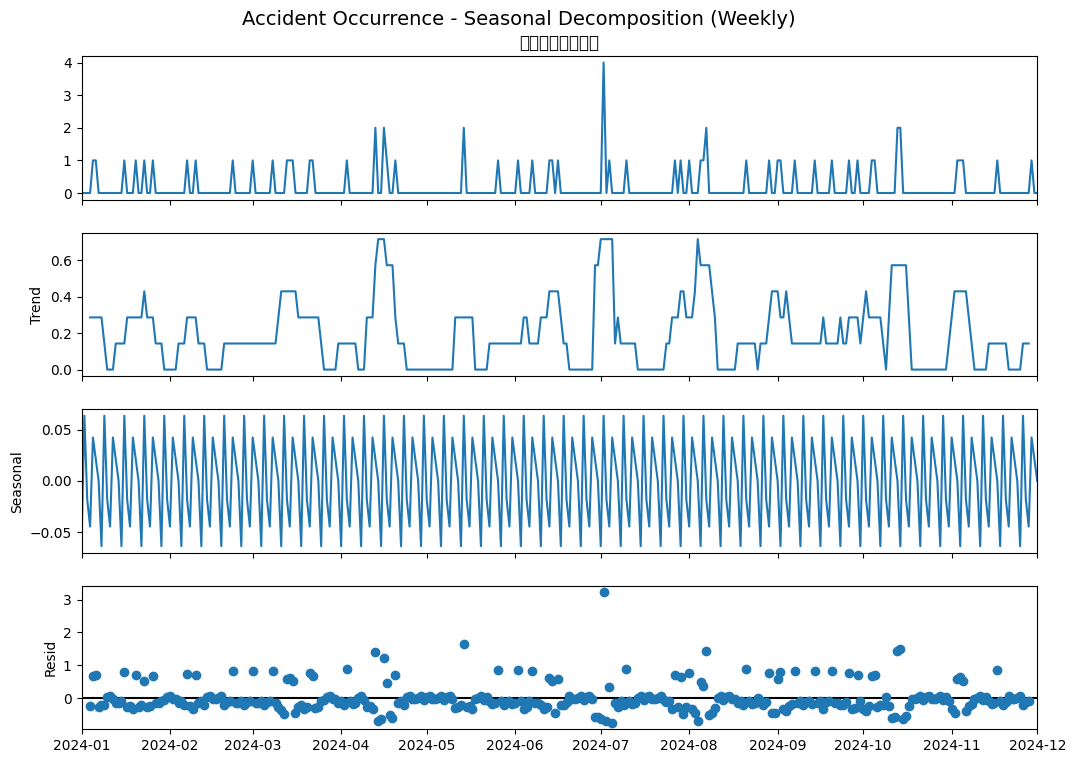

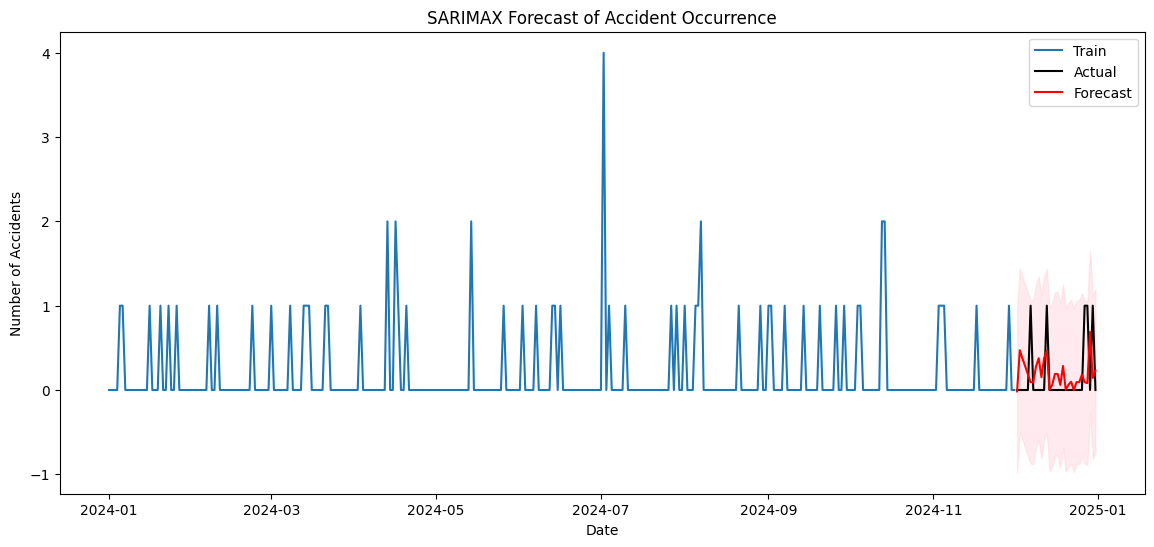

โอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:
2024-12-02     0.000000
2024-12-03    47.162059
2024-12-04    37.312097
2024-12-05    28.091006
2024-12-06    18.620658
Freq: D, Name: predicted_mean, dtype: float64


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- Load & prepare ---
df = pd.read_csv("acc_data_final_with_daynight.csv")
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
df = df.sort_values("datetime")

# รวมเป็นรายวัน (จำนวนครั้งที่เกิดเหตุ)
daily = df.resample("D", on="datetime")["เกิดเหตุ"].sum()

# แยก train / test (เดือนสุดท้ายไว้เป็น actual)
train = daily.iloc[:-30]
test = daily.iloc[-30:]

# --- Seasonal Decomposition (weekly) ---
decomp = seasonal_decompose(train, model="additive", period=7)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Accident Occurrence - Seasonal Decomposition (Weekly)", fontsize=14)
plt.show()

# --- Fit SARIMAX ---
model = SARIMAX(train,
                order=(1,0,1),
                seasonal_order=(1,1,1,30),
                enforce_stationarity=False,
                enforce_invertibility=False)
result = model.fit(disp=False)

# --- Forecast ---
forecast = result.get_forecast(steps=len(test))
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

# ให้ index ของ conf_int เป็น datetime เช่นเดียวกับ pred_mean
conf_int.index = pred_mean.index

# --- Visualization ---
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(pred_mean.index, pred_mean, label="Forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                 color="pink", alpha=0.3)
plt.title("SARIMAX Forecast of Accident Occurrence")
plt.xlabel("Date")
plt.ylabel("Number of Accidents")
plt.legend()
plt.show()

# --- Convert forecast to probability (%) ---
# 1) ตัดค่าติดลบออก
pred_pos = pred_mean.clip(lower=0)
# 2) แปลงเป็นโอกาสที่จะมีอุบัติเหตุ >=1 (ประมาณเป็น min(x,1))
prob_forecast = pred_pos.apply(lambda x: min(x,1)) * 100
print("โอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:")
print(prob_forecast.head())


In [5]:
from statsmodels.tsa.stattools import adfuller

# สมมติว่ามี series ชื่อ daily (จำนวนเกิดเหตุ/วัน)
result = adfuller(daily, autolag='AIC')

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Used lag:", result[2])
print("Number of observations:", result[3])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value:.3f}")

if result[1] < 0.05:
    print("=> p-value < 0.05 → ปฏิเสธ H0 → series นิ่ง (stationary)")
else:
    print("=> p-value >= 0.05 → ไม่ปฏิเสธ H0 → series ไม่นิ่ง")


ADF Statistic: -17.682408796332446
p-value: 3.603111581518456e-30
Used lag: 0
Number of observations: 365
Critical Values:
   1%: -3.448
   5%: -2.869
   10%: -2.571
=> p-value < 0.05 → ปฏิเสธ H0 → series นิ่ง (stationary)


C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1284603976.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  fig.tight_layout()
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  fig.tight_layout()
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  fig.tight_layout()
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\seasonal.py:360: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  fig.tight_

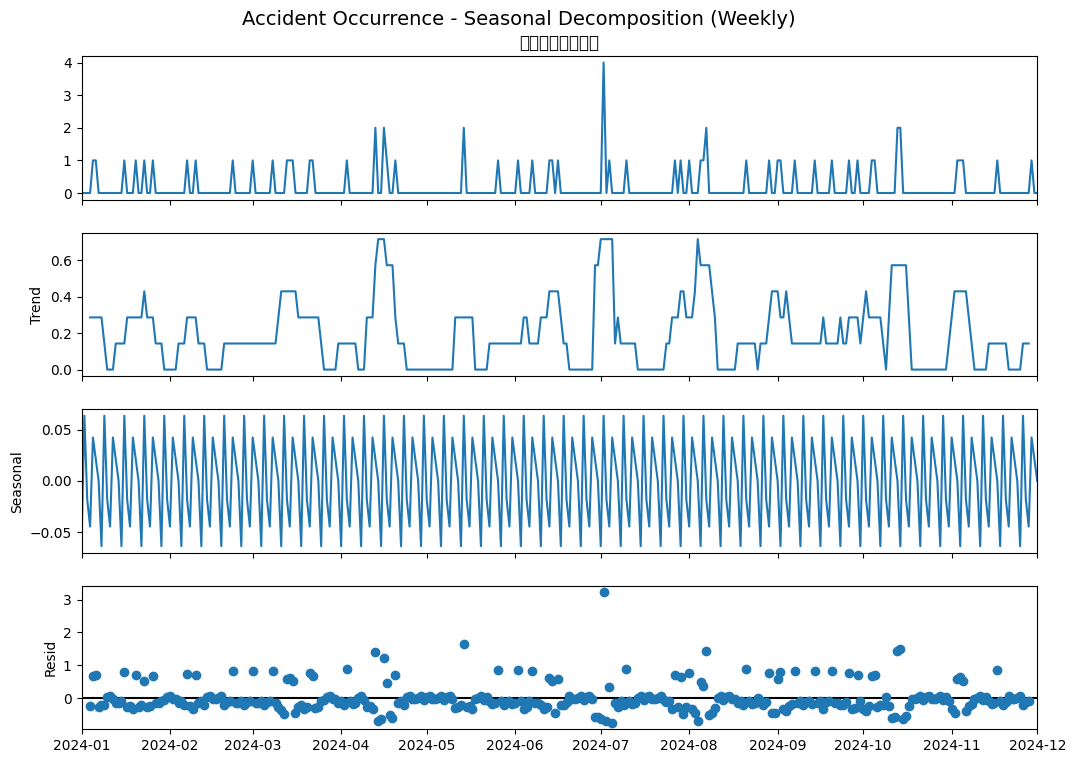

d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\scraping_test\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
d:\scraping_test\venv\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                           เกิดเหตุ   No. Observations:                  336
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 30)   Log Likelihood                -207.785
Date:                            Thu, 18 Sep 2025   AIC                            437.569
Time:                                    01:35:14   BIC                            477.314
Sample:                                01-01-2024   HQIC                           453.522
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
temperature_F             0.0114      0.027      0.425      0.671      -0.041       0.064
hu

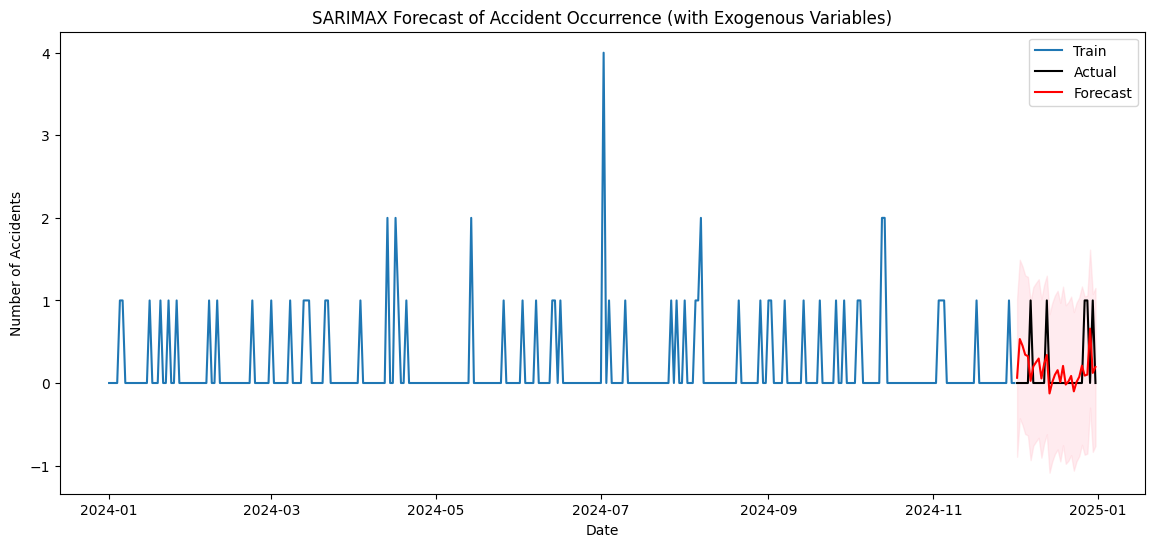

โอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:
2024-12-02     6.353495
2024-12-03    53.246250
2024-12-04    45.249034
2024-12-05    34.245232
2024-12-06    32.495095
Freq: D, Name: predicted_mean, dtype: float64


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ===============================
# 1) Load & prepare data
# ===============================
df = pd.read_csv("acc_data_final_with_daynight.csv")
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
df = df.sort_values("datetime")

# รวมจำนวนเกิดเหตุรายวัน
daily = df.resample("D", on="datetime")["เกิดเหตุ"].sum()

# เก็บ 30 วันสุดท้ายไว้ตรวจสอบ
train = daily.iloc[:-30]
test = daily.iloc[-30:]

# ===============================
# 2) Prepare exogenous variables (x)
# ===============================
exog_cols = ["temperature_F", "humidity_%", "pressure_in",
             "รถน้อยกว่า4ล้อทั้งหมด", "รถ4ล้อทั้งหมด", "รถมากกว่า4ล้อทั้งหมด"]

# สรุปค่าเฉลี่ย exog รายวัน
exog_daily = df.groupby(df["datetime"].dt.date)[exog_cols].mean()
exog_daily.index = pd.to_datetime(exog_daily.index)

# แบ่ง train/test ให้ตรงกับ y
exog_train = exog_daily.loc[train.index]
exog_test = exog_daily.loc[test.index]

# ===============================
# 3) Seasonal decomposition (optional)
# ===============================
decomp = seasonal_decompose(train, model="additive", period=7)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.suptitle("Accident Occurrence - Seasonal Decomposition (Weekly)", fontsize=14)
plt.show()

# ===============================
# 4) Fit SARIMAX + X
# ===============================
model = SARIMAX(
    train,
    exog=exog_train,
    order=(1, 0, 1),              # d=0 เพราะ series stationary
    seasonal_order=(1, 1, 1, 30), # seasonality ประมาณเดือน
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)

print(result.summary())

# ===============================
# 5) Forecast
# ===============================
forecast = result.get_forecast(steps=len(test), exog=exog_test)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int()
conf_int.index = pred_mean.index  # ให้ index ตรงกัน

# ===============================
# 6) Visualization
# ===============================
plt.figure(figsize=(14,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(pred_mean.index, pred_mean, label="Forecast", color="red")
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1],
                 color="pink", alpha=0.3)
plt.title("SARIMAX Forecast of Accident Occurrence (with Exogenous Variables)")
plt.xlabel("Date")
plt.ylabel("Number of Accidents")
plt.legend()
plt.show()

# ===============================
# 7) Convert forecast to probability (%)
# ===============================
pred_pos = pred_mean.clip(lower=0)           # ตัดค่าติดลบ
prob_forecast = pred_pos.apply(lambda x: min(x, 1)) * 100  # โอกาสเกิด >=1
print("โอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:")
print(prob_forecast.head())


C:\Users\freed\AppData\Local\Temp\ipykernel_23200\2172473523.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])


==== Logistic Regression ====
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        25
           1       0.17      0.20      0.18         5

    accuracy                           0.70        30
   macro avg       0.50      0.50      0.50        30
weighted avg       0.72      0.70      0.71        30

ROC-AUC: 0.45600000000000007

==== RandomForest ====
              precision    recall  f1-score   support

           0       0.86      0.96      0.91        25
           1       0.50      0.20      0.29         5

    accuracy                           0.83        30
   macro avg       0.68      0.58      0.60        30
weighted avg       0.80      0.83      0.80        30

ROC-AUC: 0.644


<Figure size 800x600 with 0 Axes>

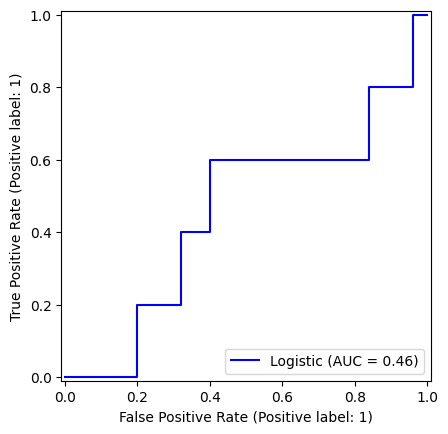

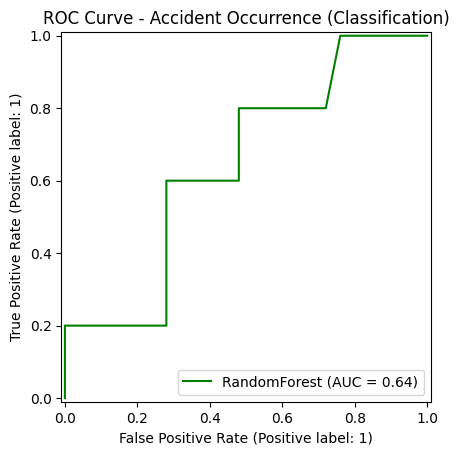


โอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:
        date  probability_%  actual
0 2024-12-02      56.666667       0
1 2024-12-03      20.000000       0
2 2024-12-04      46.666667       0
3 2024-12-05      24.000000       0
4 2024-12-06      41.000000       0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ===============================
# 1) Load & prepare data
# ===============================
df = pd.read_csv("acc_data_final_with_daynight.csv")
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
df = df.sort_values("datetime")

# รวมเป็นรายวัน (target = 1 ถ้ามีเหตุ >=1)
daily = df.resample("D", on="datetime").agg({
    "เกิดเหตุ": "sum",
    "temperature_F": "mean",
    "humidity_%": "mean",
    "pressure_in": "mean",
    "รถน้อยกว่า4ล้อทั้งหมด": "mean",
    "รถ4ล้อทั้งหมด": "mean",
    "รถมากกว่า4ล้อทั้งหมด": "mean"
})
daily["target"] = (daily["เกิดเหตุ"] >= 1).astype(int)

# split train/test (เดือนสุดท้ายไว้ test)
train = daily.iloc[:-30]
test = daily.iloc[-30:]

X_train = train.drop(columns=["เกิดเหตุ", "target"])
y_train = train["target"]
X_test = test.drop(columns=["เกิดเหตุ", "target"])
y_test = test["target"]

# ===============================
# 2) Oversampling (optional)
# ===============================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# ===============================
# 3) Logistic Regression
# ===============================
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

log_clf = LogisticRegression(class_weight="balanced", max_iter=200)
log_clf.fit(X_res_scaled, y_res)

y_pred_log = log_clf.predict(X_test_scaled)
y_prob_log = log_clf.predict_proba(X_test_scaled)[:,1]

print("==== Logistic Regression ====")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

# ===============================
# 4) RandomForest (tree-based)
# ===============================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_res, y_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\n==== RandomForest ====")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# ===============================
# 5) Visualize ROC curves
# ===============================
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic", color="blue")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="RandomForest", color="green")
plt.title("ROC Curve - Accident Occurrence (Classification)")
plt.show()

# ===============================
# 6) Predict probability (future / test)
# ===============================
pred_prob = rf.predict_proba(X_test)[:,1] * 100
prob_df = pd.DataFrame({
    "date": X_test.index,
    "probability_%": pred_prob,
    "actual": y_test.values
})
print("\nโอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:")
print(prob_df.head())


scale_pos_weight = 5.11


d:\scraping_test\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [02:26:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


==== XGBoost ====
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.33      0.40      0.36         5

    accuracy                           0.77        30
   macro avg       0.60      0.62      0.61        30
weighted avg       0.78      0.77      0.77        30

ROC-AUC: 0.688
[LightGBM] [Info] Number of positive: 281, number of negative: 281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 921
[LightGBM] [Info] Number of data points in the train set: 562, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

<Figure size 1000x800 with 0 Axes>

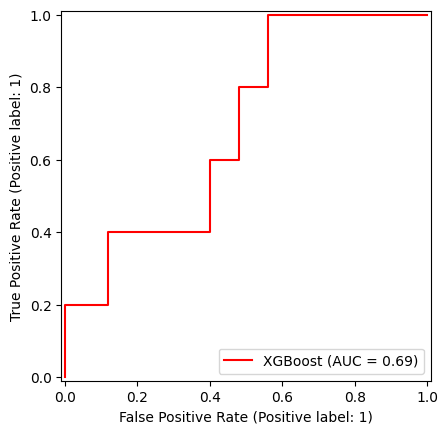

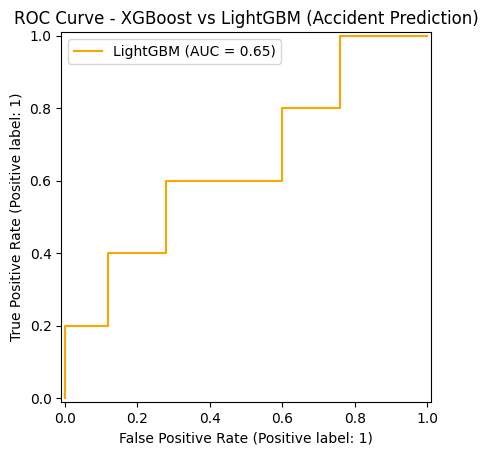


โอกาสเกิดเหตุ (%) ตาม LightGBM ใน 5 วันแรกของช่วงทดสอบ:
        date  probability_%  actual
0 2024-12-02          99.30       0
1 2024-12-03           0.02       0
2 2024-12-04          65.28       0
3 2024-12-05           8.31       0
4 2024-12-06          54.16       0


In [18]:
# ==================================================
# XGBoost + LightGBM สำหรับไฟล์ acc_data_daily_clean_enriched.csv
# ==================================================
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb

# ===============================
# 1) Load & prepare data จากไฟล์รายวันที่ clean แล้ว
# ===============================
df = pd.read_csv("acc_data_daily_clean_enriched.csv", parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()

# สร้าง target: 1 ถ้ามีเหตุ >=1
df["target"] = (df["เกิดเหตุ"] >= 1).astype(int)

# split train/test (เดือนสุดท้าย 30 วันไว้ test)
train = df.iloc[:-30]
test = df.iloc[-30:]

# ลบเฉพาะคอลัมน์ที่ไม่ใช้เป็น feature
X_train = train.drop(columns=["เกิดเหตุ", "target"])
y_train = train["target"]
X_test = test.drop(columns=["เกิดเหตุ", "target"])
y_test = test["target"]

# ===============================
# 2) Oversampling ด้วย SMOTE
# ===============================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# คำนวณ scale_pos_weight (จาก train set เดิม)
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# ===============================
# 3) XGBoost Classifier
# ===============================
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_res, y_res)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]

print("==== XGBoost ====")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

# ===============================
# 4) LightGBM Classifier
# ===============================
lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    class_weight='balanced'
)
lgb_clf.fit(X_res, y_res)

y_pred_lgb = lgb_clf.predict(X_test)
y_prob_lgb = lgb_clf.predict_proba(X_test)[:,1]

print("\n==== LightGBM ====")
print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))

# ===============================
# 5) Visualize ROC curves
# ===============================
plt.figure(figsize=(10,8))
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", color="red")
RocCurveDisplay.from_predictions(y_test, y_prob_lgb, name="LightGBM", color="orange")
plt.title("ROC Curve - XGBoost vs LightGBM (Accident Prediction)")
plt.legend()
plt.show()

# ===============================
# 6) แสดง probability 5 วันแรก
# ===============================
pred_prob_lgb = lgb_clf.predict_proba(X_test)[:,1] * 100
prob_df_lgb = pd.DataFrame({
    "date": X_test.index,
    "probability_%": pred_prob_lgb.round(2),
    "actual": y_test.values
})
print("\nโอกาสเกิดเหตุ (%) ตาม LightGBM ใน 5 วันแรกของช่วงทดสอบ:")
print(prob_df_lgb.head())

In [11]:
# ==================================================
# บล็อคใหม่: XGBoost + ปรับ Threshold = 0.25 (เพื่อเพิ่ม Recall)
# ==================================================
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1) Load & prepare data (เหมือนเดิม)
# ===============================
df = pd.read_csv("acc_data_final_with_daynight.csv")
df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
df = df.sort_values("datetime")

# รวมเป็นรายวัน (target = 1 ถ้ามีเหตุ >=1)
daily = df.resample("D", on="datetime").agg({
    "เกิดเหตุ": "sum",
    "temperature_F": "mean",
    "humidity_%": "mean",
    "pressure_in": "mean",
    "รถน้อยกว่า4ล้อทั้งหมด": "mean",
    "รถ4ล้อทั้งหมด": "mean",
    "รถมากกว่า4ล้อทั้งหมด": "mean"
})
daily["target"] = (daily["เกิดเหตุ"] >= 1).astype(int)

# split train/test (เดือนสุดท้ายไว้ test)
train = daily.iloc[:-30]
test = daily.iloc[-30:]

X_train = train.drop(columns=["เกิดเหตุ", "target"])
y_train = train["target"]
X_test = test.drop(columns=["เกิดเหตุ", "target"])
y_test = test["target"]

# ===============================
# 2) Oversampling (เหมือนเดิม)
# ===============================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# คำนวณ scale_pos_weight
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0

# ===============================
# 3) Train XGBoost (เหมือนเดิม)
# ===============================
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_clf.fit(X_res, y_res)

# ทำนาย probability
y_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]

# ===============================
# 4) ปรับ Threshold → 0.25
# ===============================
THRESHOLD = 0.25
y_pred_custom = (y_prob_xgb >= THRESHOLD).astype(int)

print(f"\n==== XGBoost + Threshold = {THRESHOLD} ====")
print(classification_report(y_test, y_pred_custom))
print("ROC-AUC (ยังใช้ probability เดิม):", roc_auc_score(y_test, y_prob_xgb))

# Confusion Matrix (optional)
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

# ===============================
# 5) แสดงตารางผลลัพธ์: วันที่, ความน่าจะเป็น, actual, predicted
# ===============================
result_df = pd.DataFrame({
    "date": X_test.index.strftime('%Y-%m-%d'),
    "prob_%": (y_prob_xgb * 100).round(2),
    "actual": y_test.values,
    "predicted": y_pred_custom
})

print(f"\n📊 ผลลัพธ์ 10 วันแรก (Threshold = {THRESHOLD}):")
print(result_df.head(10))

# ไฮไลต์เฉพาะวันที่โมเดลจับเหตุได้ (actual=1)
print(f"\n✅ วันที่เกิดเหตุจริง (actual=1) และโมเดลทำนายว่า 'มีเหตุ' (predicted=1):")
hits = result_df[(result_df['actual'] == 1) & (result_df['predicted'] == 1)]
print(hits if not hits.empty else "❌ ไม่มีวันที่จับเหตุได้")

print(f"\n⚠️ วันที่ไม่มีเหตุ แต่โมเดลเตือนผิด (False Alarm):")
false_alarms = result_df[(result_df['actual'] == 0) & (result_df['predicted'] == 1)]
print(false_alarms if not false_alarms.empty else "✅ ไม่มี false alarm")

C:\Users\freed\AppData\Local\Temp\ipykernel_23200\743636073.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["datetime"] = pd.to_datetime(df["date"] + " " + df["time"])
d:\scraping_test\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [01:47:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



==== XGBoost + Threshold = 0.25 ====
              precision    recall  f1-score   support

           0       0.86      0.76      0.81        25
           1       0.25      0.40      0.31         5

    accuracy                           0.70        30
   macro avg       0.56      0.58      0.56        30
weighted avg       0.76      0.70      0.73        30

ROC-AUC (ยังใช้ probability เดิม): 0.768

Confusion Matrix:
[[19  6]
 [ 3  2]]

📊 ผลลัพธ์ 10 วันแรก (Threshold = 0.25):
         date     prob_%  actual  predicted
0  2024-12-02  96.339996       0          1
1  2024-12-03   3.940000       0          0
2  2024-12-04  68.029999       0          1
3  2024-12-05  25.740000       0          1
4  2024-12-06  64.919998       0          1
5  2024-12-07   4.700000       1          0
6  2024-12-08   0.150000       0          0
7  2024-12-09   4.370000       0          0
8  2024-12-10  75.290001       0          1
9  2024-12-11   1.690000       0          0

✅ วันที่เกิดเหตุจริง (actual=1

📊 โครงสร้างข้อมูล:
            เกิดเหตุ  temperature_F  humidity_%  pressure_in  \
datetime                                                       
2024-01-01         0      81.312500   83.020833    29.757292   
2024-01-02         0      80.916667   80.916667    29.838333   
2024-01-03         0      83.125000   77.291667    29.747500   
2024-01-04         0      84.625000   78.604167    29.716042   
2024-01-05         1      86.375000   76.645833    29.586875   

            รถน้อยกว่า4ล้อทั้งหมด  รถ4ล้อทั้งหมด  รถมากกว่า4ล้อทั้งหมด  \
datetime                                                                 
2024-01-01               1.937500       8.958333              1.937500   
2024-01-02               1.895833       9.229167              1.791667   
2024-01-03               1.937500       9.083333              1.895833   
2024-01-04               1.833333       9.166667              1.979167   
2024-01-05               1.916667       8.979167              1.937500   

            d

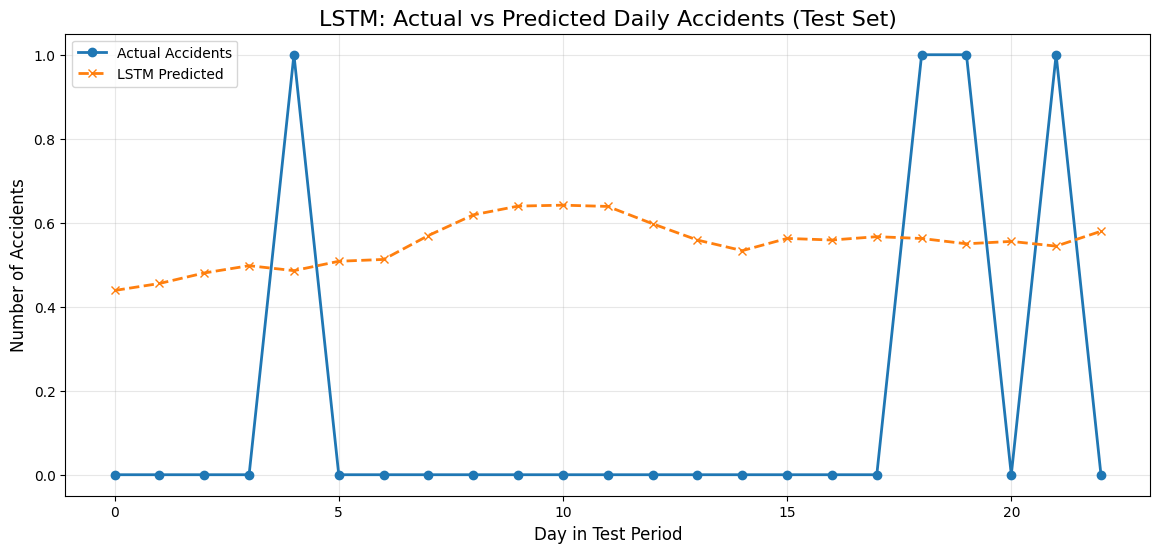


📋 10 วันแรกในช่วงทดสอบ:
      date  actual  predicted
2024-12-09     0.0       0.44
2024-12-10     0.0       0.46
2024-12-11     0.0       0.48
2024-12-12     0.0       0.50
2024-12-13     1.0       0.49
2024-12-14     0.0       0.51
2024-12-15     0.0       0.51
2024-12-16     0.0       0.57
2024-12-17     0.0       0.62
2024-12-18     0.0       0.64


In [17]:
# ==================================================
# LSTM สำหรับพยากรณ์อุบัติเหตุรายวัน — ใช้ไฟล์ acc_data_daily_enriched.csv
# ==================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# ===============================
# 1) โหลดข้อมูลรายวันที่เตรียมไว้
# ===============================
df = pd.read_csv("acc_data_daily_enriched.csv", parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()

print("📊 โครงสร้างข้อมูล:")
print(df.head())
print(f"✅ จำนวนวันทั้งหมด: {len(df)}")

# ===============================
# 2) เตรียม X (features) และ y (target)
# ===============================
target_col = "เกิดเหตุ"
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].values  # features ทั้งหมด (อุณหภูมิ, ความชื้น, รถ, วัน, ฯลฯ)
y = df[target_col].values    # target = จำนวนอุบัติเหตุรายวัน

# แบ่ง train/test — เดือนสุดท้าย 30 วันเป็น test
n_test = 30
X_train, X_test = X[:-n_test], X[-n_test:]
y_train, y_test = y[:-n_test], y[-n_test:]

# ===============================
# 3) Scaling (LSTM ไวต่อ scale)
# ===============================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# ===============================
# 4) สร้าง Sequence สำหรับ LSTM
# ===============================
def create_sequences(X, y, time_steps=30):
    X_seq, y_seq = [], []
    for i in range(len(X) - time_steps):
        X_seq.append(X[i:i + time_steps])
        y_seq.append(y[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

TIME_STEPS = 7  # ใช้ข้อมูล 7 วันก่อนหน้า → ทำนายวันที่ 8

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, TIME_STEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, TIME_STEPS)

print(f"\n🔁 รูปแบบข้อมูลสำหรับ LSTM:")
print(f"Train sequences: {X_train_seq.shape} → y: {y_train_seq.shape}")
print(f"Test sequences:  {X_test_seq.shape} → y: {y_test_seq.shape}")

# ===============================
# 5) สร้างโมเดล LSTM + ปรับ sample_weight
# ===============================
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(TIME_STEPS, X_train_seq.shape[2])),
    LSTM(30, return_sequences=False),
    Dense(15, activation='relu'),
    Dense(1, activation='linear')  # regression
])

# ให้น้ำหนักสูงกับวันที่มีอุบัติเหตุ > 0
sample_weight = np.where(y_train_seq > 0.1, 5.0, 1.0)  # 5x weight ถ้ามีเหตุ

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# ===============================
# 6) Train โมเดล
# ===============================
print("\n🚀 เริ่มเทรนโมเดล...")
history = model.fit(
    X_train_seq, y_train_seq,
    sample_weight=sample_weight,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# ===============================
# 7) ประเมินผลบน Test Set
# ===============================
y_pred_scaled = model.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled).flatten()
y_true = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"\n✅ ผลลัพธ์บน Test Set (30 วันสุดท้าย):")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

# ===============================
# 8) พล็อตกราฟเปรียบเทียบ
# ===============================
plt.figure(figsize=(14, 6))
days = np.arange(len(y_true))

plt.plot(days, y_true, label='Actual Accidents', marker='o', linewidth=2)
plt.plot(days, y_pred, label='LSTM Predicted', marker='x', linestyle='--', linewidth=2)

plt.title('LSTM: Actual vs Predicted Daily Accidents (Test Set)', fontsize=16)
plt.xlabel('Day in Test Period', fontsize=12)
plt.ylabel('Number of Accidents', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ===============================
# 9) แสดงตาราง 10 วันแรก
# ===============================
result_df = pd.DataFrame({
    "date": df.index[-len(y_true):][:10],  # ปรับ index ให้ตรงกับช่วง test
    "actual": y_true[:10],
    "predicted": y_pred[:10].round(2)
})
print("\n📋 10 วันแรกในช่วงทดสอบ:")
print(result_df.to_string(index=False))

scale_pos_weight = 5.11


d:\scraping_test\venv\lib\site-packages\xgboost\training.py:183: UserWarning: [02:33:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 281, number of negative: 281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 921
[LightGBM] [Info] Number of data points in the train set: 562, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:121: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:121: UserWarning: Glyph 3606 (\N{THAI CHARACTER THO THUNG}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:121: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:121: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:121: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:121: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from current font.
  p

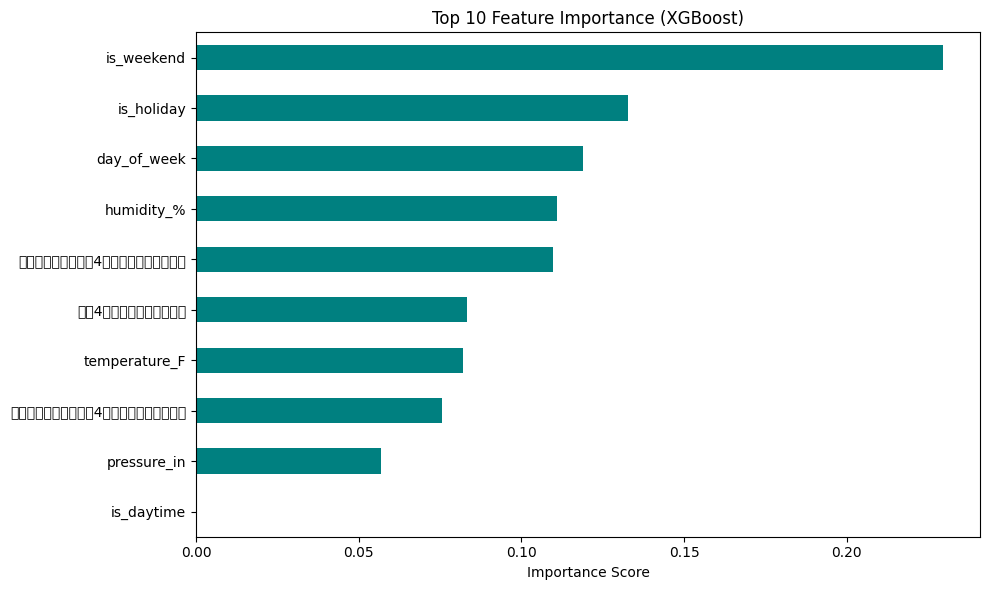

<Figure size 1000x800 with 0 Axes>

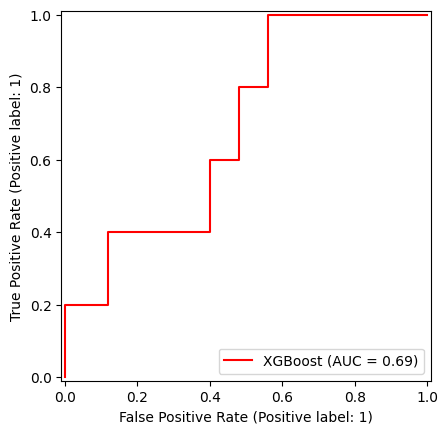

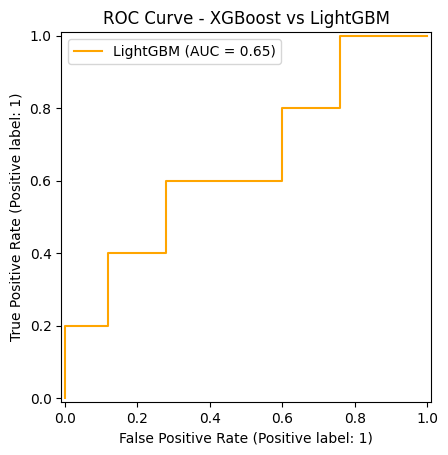

C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:160: UserWarning: Glyph 3648 (\N{THAI CHARACTER SARA E}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:160: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:160: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:160: UserWarning: Glyph 3640 (\N{THAI CHARACTER SARA U}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:160: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from current font.
  plt.tight_layout()
C:\Users\freed\AppData\Local\Temp\ipykernel_23200\1844959915.py:160: UserWarning: Glyph 3636 (\N{THAI CHARACTER SARA I}) missing from current font.
  plt.t

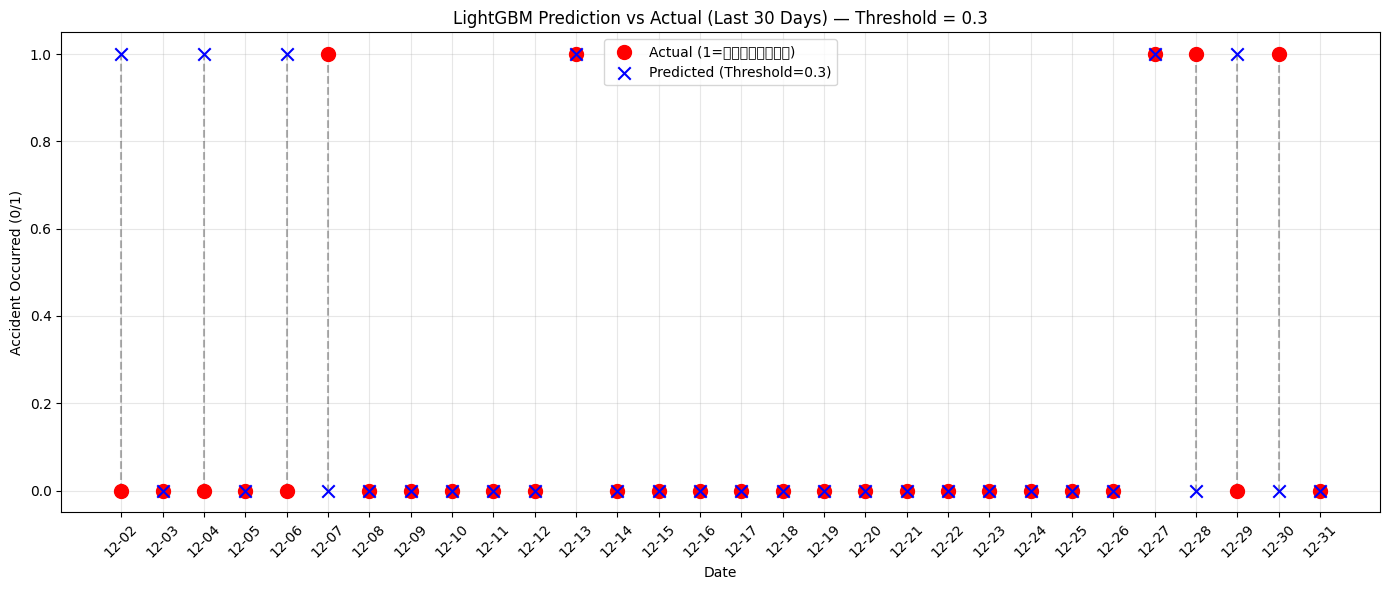

In [ ]:
# ==================================================
# XGBoost + LightGBM (ปรับปรุงขั้นสุดท้าย) — พร้อม F1-Score คลาส 1 + กราฟการทำนายรายวัน
# ==================================================
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb

# ===============================
# 1) Load & prepare data
# ===============================
df = pd.read_csv("acc_data_daily_clean_enriched.csv", parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()
df["target"] = (df["เกิดเหตุ"] >= 1).astype(int)

train = df.iloc[:-30]
test = df.iloc[-30:]

X_train = train.drop(columns=["เกิดเหตุ", "target"])
y_train = train["target"]
X_test = test.drop(columns=["เกิดเหตุ", "target"])
y_test = test["target"]

# ===============================
# 2) SMOTE + scale_pos_weight
# ===============================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# ===============================
# 3) Train XGBoost & LightGBM
# ===============================
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_res, y_res)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    class_weight='balanced'
)
lgb_clf.fit(X_res, y_res)

# ===============================
# 

# ===============================
# 6) Top-5 วันที่มีโอกาสเกิดเหตุสูงสุด
# ===============================
top_n = 5
prob_df = pd.DataFrame({
    "date": X_test.index,
    "prob_%": (y_prob_lgb * 100).round(2),
    "actual": y_test.values,
    "predicted": y_pred_lgb_adj
}).sort_values("prob_%", ascending=False).head(top_n)

print(f"\n🔝 Top-{top_n} วันที่มีโอกาสเกิดเหตุสูงสุด (LightGBM):")
print(prob_df.to_string(index=False))

# ===============================
# 7) Feature Importance (XGBoost)
# ===============================
plt.figure(figsize=(10,6))
feat_importances = pd.Series(xgb_clf.feature_importances_, index=X_train.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importance (XGBoost)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ===============================
# 8) ROC Curve
# ===============================
plt.figure(figsize=(10,8))
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost", color="red")
RocCurveDisplay.from_predictions(y_test, y_prob_lgb, name="LightGBM", color="orange")
plt.title("ROC Curve - XGBoost vs LightGBM")
plt.legend()
plt.show()

# ===============================
# 9) ✅ พล็อตกราฟ: การทำนาย (threshold=0.3) vs ค่าจริง ตลอด 30 วันสุดท้าย
# ===============================
plt.figure(figsize=(14, 6))

# สร้างแกน x = วันที่
dates = X_test.index
x_pos = range(len(dates))

# พล็อตค่าจริง (actual)
plt.scatter(x_pos, y_test, color='red', label='Actual (1=เหตุเกิด)', marker='o', s=100, zorder=5)

# พล็อตค่าทำนาย (predicted)
plt.scatter(x_pos, y_pred_lgb_adj, color='blue', label=f'Predicted (Threshold={THRESHOLD})', marker='x', s=80, zorder=5)

# เชื่อม Actual vs Predicted ด้วยเส้นประ (optional)
for i in range(len(dates)):
    plt.plot([x_pos[i], x_pos[i]], [y_test.iloc[i], y_pred_lgb_adj[i]], 'k--', alpha=0.3)

# ตกแต่งกราฟ
plt.xticks(x_pos, [d.strftime('%m-%d') for d in dates], rotation=45)
plt.xlabel('Date')
plt.ylabel('Accident Occurred (0/1)')
plt.title(f'LightGBM Prediction vs Actual (Last 30 Days) — Threshold = {THRESHOLD}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:

# ===============================
y_prob_xgb = xgb_clf.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)

y_prob_lgb = lgb_clf.predict_proba(X_test)[:,1]
y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)

print("==== XGBoost (Threshold=0.5) ====")
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print("\n==== LightGBM (Threshold=0.5) ====")
print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lgb))

# ===============================
# 5) ปรับ Threshold → 0.3 เพื่อเพิ่ม Recall
# ===============================
THRESHOLD = 0.3
y_pred_lgb_adj = (y_prob_lgb >= THRESHOLD).astype(int)

print(f"\n==== LightGBM (Threshold={THRESHOLD}) ====")
report = classification_report(y_test, y_pred_lgb_adj, output_dict=True)
print(classification_report(y_test, y_pred_lgb_adj))

# ✅ ดึง F1-Score ของคลาส 1 (เหตุเกิด) มาแสดงเด่นๆ
f1_class_1 = report['1']['f1-score']
print(f"\n🎯 F1-Score สำหรับคลาส 'เหตุเกิด (1)': {f1_class_1:.4f}")

# Confusion Matrix
print("\nConfusion Matrix (LightGBM, Threshold=0.3):")
cm = confusion_matrix(y_test, y_pred_lgb_adj)
print(cm)

==== XGBoost (Threshold=0.5) ====
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.33      0.40      0.36         5

    accuracy                           0.77        30
   macro avg       0.60      0.62      0.61        30
weighted avg       0.78      0.77      0.77        30

ROC-AUC: 0.688

==== LightGBM (Threshold=0.5) ====
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.33      0.40      0.36         5

    accuracy                           0.77        30
   macro avg       0.60      0.62      0.61        30
weighted avg       0.78      0.77      0.77        30

ROC-AUC: 0.648

==== LightGBM (Threshold=0.3) ====
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.33      0.40      0.36         5

    accuracy                           0.77   

In [2]:
import pandas as pd
import numpy as np

# --- 1. โหลดข้อมูล ---
df = pd.read_csv("acc_data_final_with_daynight.csv")  # แก้ path ให้ตรงกับไฟล์ของคุณ

# --- 2. สร้าง datetime จาก date + time ---
df['datetime'] = pd.to_datetime(df['date'] + " " + df['time'])

# --- 3. สร้าง column date (แค่วัน) ---
df['date_only'] = df['datetime'].dt.date

# --- 4. รวมข้อมูลเป็นรายวัน ---
df_daily = df.groupby('date_only').agg({
    'เกิดเหตุ': 'sum',
    'รถน้อยกว่า4ล้อทั้งหมด': 'sum',
    'รถ4ล้อทั้งหมด': 'sum',
    'รถมากกว่า4ล้อทั้งหมด': 'sum'
}).reset_index()

# --- 5. สร้าง datetime column ใหม่จาก date_only ---
df_daily['datetime'] = pd.to_datetime(df_daily['date_only'])

# --- 6. เพิ่ม month และ week_of_year ---
df_daily['month'] = df_daily['datetime'].dt.month
df_daily['week_of_year'] = df_daily['datetime'].dt.isocalendar().week

# --- 7. สร้าง is_weekend ---
df_daily['is_weekend'] = df_daily['datetime'].dt.weekday >= 5

# --- 8. สร้าง is_holiday (ตัวอย่างวันหยุดไทย) ---
thai_holidays = [
    "2024-01-01", "2024-04-13", "2024-04-14", "2024-04-15", "2024-05-01", "2024-12-05"
]
df_daily['is_holiday'] = df_daily['datetime'].dt.date.astype(str).isin(thai_holidays).astype(int)

# --- 9. เลือกคอลัมน์ที่ต้องการ ---
columns_to_keep = [
    'datetime',
    'is_weekend',
    'is_holiday',
    'รถน้อยกว่า4ล้อทั้งหมด',
    'รถ4ล้อทั้งหมด',
    'รถมากกว่า4ล้อทั้งหมด',
    'เกิดเหตุ',
    'month',
    'week_of_year'
]

df_final = df_daily[columns_to_keep]

# --- 10. บันทึกไฟล์ใหม่ ---
df_final.to_csv("daily_aggregated_data.csv", index=False)

print("แปลงข้อมูลรายวันเสร็จแล้ว ✅")
print(df_final.head())


C:\Users\freed\AppData\Local\Temp\ipykernel_18560\3287066489.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['datetime'] = pd.to_datetime(df['date'] + " " + df['time'])


แปลงข้อมูลรายวันเสร็จแล้ว ✅
    datetime  is_weekend  is_holiday  รถน้อยกว่า4ล้อทั้งหมด  รถ4ล้อทั้งหมด  \
0 2024-01-01       False           1                     93            430   
1 2024-01-02       False           0                     91            443   
2 2024-01-03       False           0                     93            436   
3 2024-01-04       False           0                     88            440   
4 2024-01-05       False           0                     92            431   

   รถมากกว่า4ล้อทั้งหมด  เกิดเหตุ  month  week_of_year  
0                    93         0      1             1  
1                    86         0      1             1  
2                    91         0      1             1  
3                    95         0      1             1  
4                    93         1      1             1  


==== Logistic Regression ====
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        25
           1       0.17      0.20      0.18         5

    accuracy                           0.70        30
   macro avg       0.50      0.50      0.50        30
weighted avg       0.72      0.70      0.71        30

ROC-AUC: 0.464

==== RandomForest ====
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        25
           1       0.33      0.20      0.25         5

    accuracy                           0.80        30
   macro avg       0.59      0.56      0.57        30
weighted avg       0.77      0.80      0.78        30

ROC-AUC: 0.64


<Figure size 800x600 with 0 Axes>

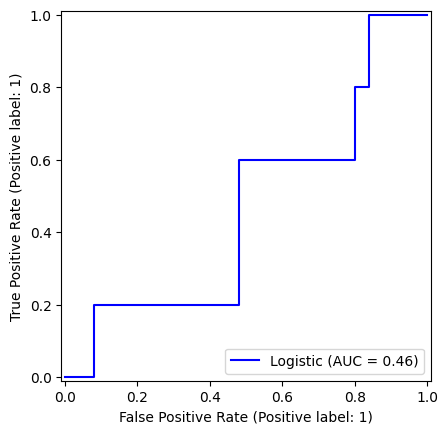

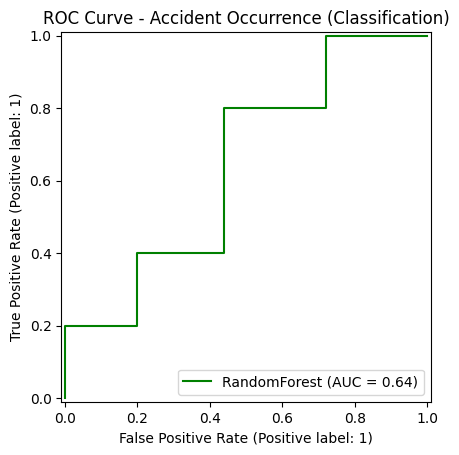


โอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:
        date  probability_%  actual
0 2024-12-02      40.000000       0
1 2024-12-03      22.666667       0
2 2024-12-04      51.000000       0
3 2024-12-05      24.000000       0
4 2024-12-06      53.333333       0


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ===============================
# 1) Load & prepare data
# ===============================
df = pd.read_csv("clean_data.csv")

# ensure datetime is parsed
df["datetime"] = pd.to_datetime(df["datetime"])

# target = 1 ถ้ามีเหตุ >=1
df["target"] = (df["เกิดเหตุ"] >= 1).astype(int)

# เลือก features ที่สำคัญ
features = [
    "temperature_F",
    "humidity_%",
    "pressure_in",
    "รถน้อยกว่า4ล้อทั้งหมด",
    "รถ4ล้อทั้งหมด",
    "รถมากกว่า4ล้อทั้งหมด",
    "day_of_week",
    "is_weekend",
    "is_holiday"
]

X = df[features]
y = df["target"]

# แบ่ง train/test (เดือนสุดท้ายไว้ test)
# ถ้า dataset สั้นเกิน แนะนำใช้ train_test_split ธรรมดา
train = df.iloc[:-30] if len(df) > 30 else df.iloc[:-5]
test = df.iloc[-30:] if len(df) > 30 else df.iloc[-5:]

X_train = train[features]
y_train = train["target"]
X_test = test[features]
y_test = test["target"]

# ===============================
# 2) Oversampling (SMOTE)
# ===============================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# ===============================
# 3) Logistic Regression
# ===============================
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

log_clf = LogisticRegression(class_weight="balanced", max_iter=200)
log_clf.fit(X_res_scaled, y_res)

y_pred_log = log_clf.predict(X_test_scaled)
y_prob_log = log_clf.predict_proba(X_test_scaled)[:, 1]

print("==== Logistic Regression ====")
print(classification_report(y_test, y_pred_log, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

# ===============================
# 4) RandomForest
# ===============================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)
rf.fit(X_res, y_res)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n==== RandomForest ====")
print(classification_report(y_test, y_pred_rf, zero_division=0))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

# ===============================
# 5) Visualize ROC curves
# ===============================
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic", color="blue")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="RandomForest", color="green")
plt.title("ROC Curve - Accident Occurrence (Classification)")
plt.show()

# ===============================
# 6) Predict probability
# ===============================
pred_prob = rf.predict_proba(X_test)[:, 1] * 100
prob_df = pd.DataFrame({
    "date": test["datetime"].values,
    "probability_%": pred_prob,
    "actual": y_test.values
})

print("\nโอกาสเกิดเหตุ (%) ใน 5 วันแรกของช่วงทดสอบ:")
print(prob_df.head())


Data size: train=336, test=30  |  pos_count=55, neg_count=281
scale_pos_weight = 5.11
[LightGBM] [Info] Number of positive: 281, number of negative: 281
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000331 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 921
[LightGBM] [Info] Number of data points in the train set: 562, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

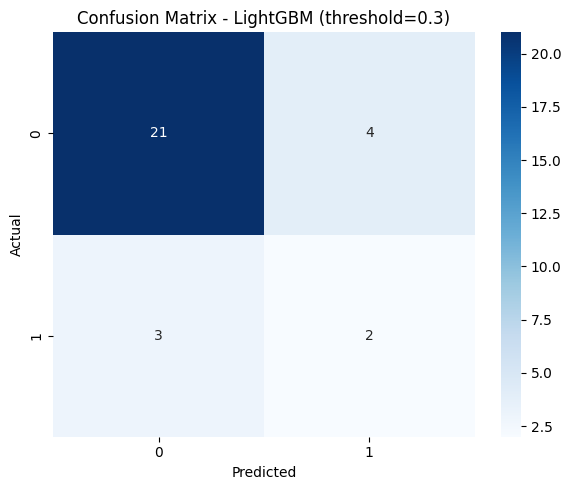


🔝 Top-5 วันที่มีโอกาสเกิดเหตุสูงสุด (LightGBM, threshold=0.3):
      date  prob_%  actual  predicted_adj
2024-12-27   99.55       1              1
2024-12-02   99.30       0              1
2024-12-29   98.27       0              1
2024-12-04   65.28       0              1
2024-12-13   56.07       1              1


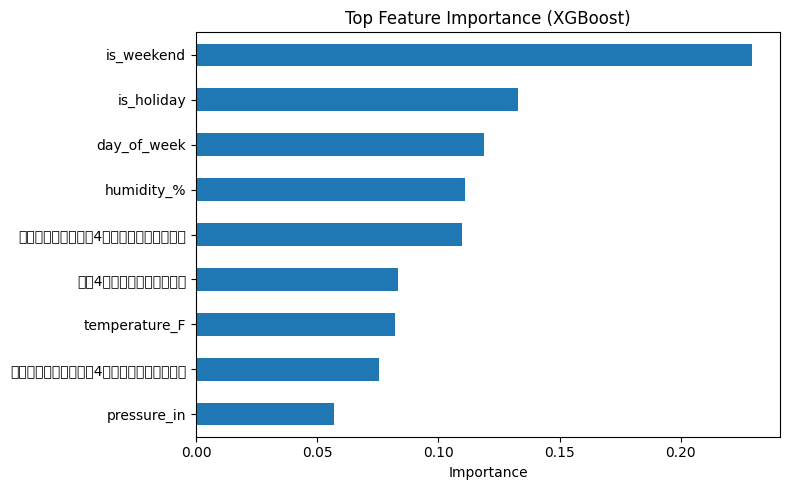

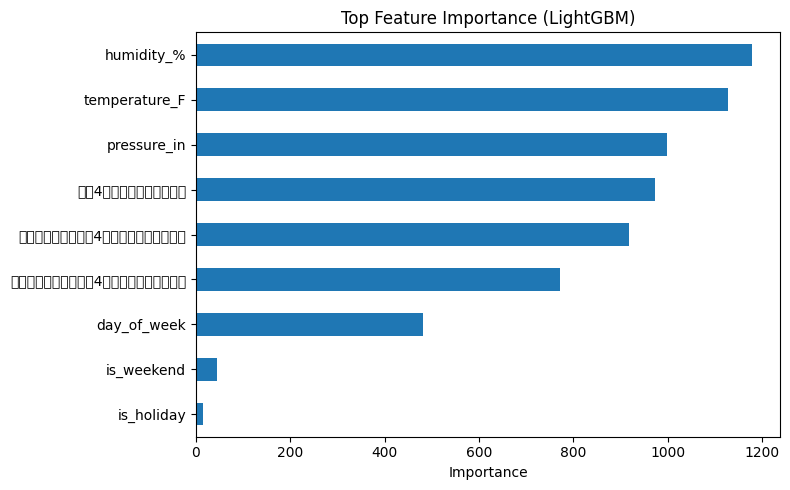

<Figure size 800x600 with 0 Axes>

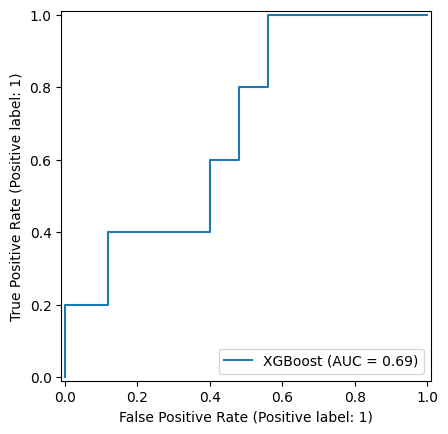

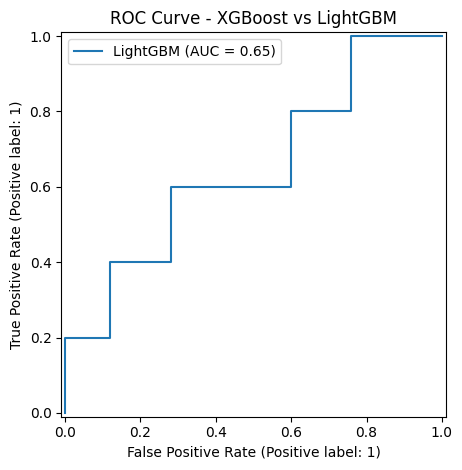

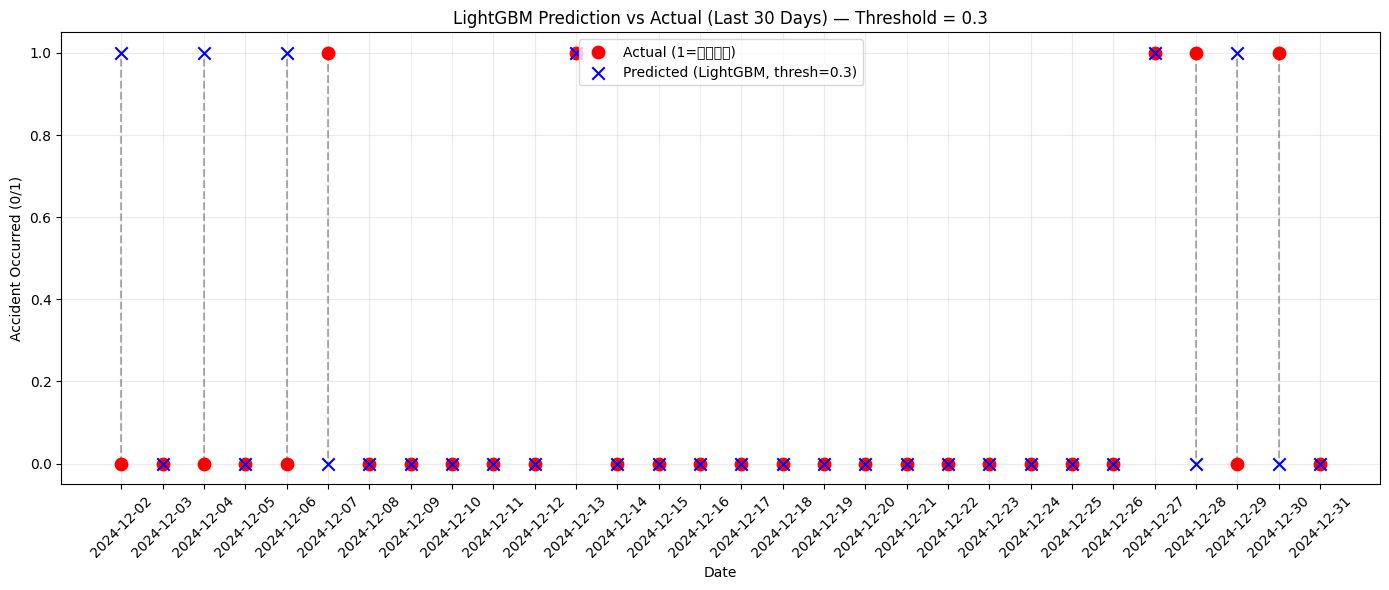

In [ ]:
# xgb_lgb_final.py
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, f1_score
import xgboost as xgb
import lightgbm as lgb

# ===============================
# Config
# ===============================
CSV_PATH = "clean_data.csv"
TEST_DAYS = 30          # ใช้ 30 วันสุดท้ายเป็น test ถ้ามีข้อมูลพอ
TOP_N = 5               # top-N วันที่มีโอกาสสูงสุด (จาก LightGBM)
THRESHOLD = 0.30        # Threshold สำหรับแปลง probability -> class

# ===============================
# 1) Load & prepare data
# ===============================
df = pd.read_csv(CSV_PATH, parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()

# ensure numeric columns exist (if column names in Thai differ, adjust)
required_cols = [
    "เกิดเหตุ",
    "temperature_F",
    "humidity_%",
    "pressure_in",
    "รถน้อยกว่า4ล้อทั้งหมด",
    "รถ4ล้อทั้งหมด",
    "รถมากกว่า4ล้อทั้งหมด",
    "day_of_week",
    "is_weekend",
    "is_holiday"
]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in CSV: {missing_cols}")

# target
df["target"] = (df["เกิดเหตุ"] >= 1).astype(int)

# Split train/test (last TEST_DAYS for test if possible, else fallback)
if len(df) > TEST_DAYS:
    train = df.iloc[:-TEST_DAYS].copy()
    test = df.iloc[-TEST_DAYS:].copy()
else:
    # fallback: use last 5 days as test
    fallback_days = 5
    train = df.iloc[:-fallback_days].copy()
    test = df.iloc[-fallback_days:].copy()

# Features to use (you can add/remove)
features = [
    "temperature_F",
    "humidity_%",
    "pressure_in",
    "รถน้อยกว่า4ล้อทั้งหมด",
    "รถ4ล้อทั้งหมด",
    "รถมากกว่า4ล้อทั้งหมด",
    "day_of_week",
    "is_weekend",
    "is_holiday"
]

X_train = train[features].copy()
y_train = train["target"].copy()
X_test = test[features].copy()
y_test = test["target"].copy()

# If any non-numeric sneaked in, convert or raise
for col in features:
    if not pd.api.types.is_numeric_dtype(X_train[col]):
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

# Fill or drop NA rows produced by coercion (simple strategy)
if X_train.isna().any().any():
    X_train = X_train.fillna(X_train.median())
if X_test.isna().any().any():
    X_test = X_test.fillna(X_train.median())

# ===============================
# 2) SMOTE + compute scale_pos_weight
# ===============================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = neg_count / pos_count if pos_count > 0 else 1.0
print(f"Data size: train={len(X_train)}, test={len(X_test)}  |  pos_count={pos_count}, neg_count={neg_count}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

# ===============================
# 3) Train XGBoost & LightGBM
# ===============================
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_res, y_res)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    class_weight='balanced'
)
lgb_clf.fit(X_res, y_res)

# ===============================
# 4) Predictions & thresholding
# ===============================
# Raw probabilities
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]
y_prob_lgb = lgb_clf.predict_proba(X_test)[:, 1]

# Default 0.5 preds
y_pred_xgb_default = (y_prob_xgb >= 0.5).astype(int)
y_pred_lgb_default = (y_prob_lgb >= 0.5).astype(int)

# Adjusted by THRESHOLD
y_pred_xgb_adj = (y_prob_xgb >= THRESHOLD).astype(int)
y_pred_lgb_adj = (y_prob_lgb >= THRESHOLD).astype(int)

# ===============================
# 5) Metrics & Reports
# ===============================
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"\n=== {name} ===")
    print(classification_report(y_true, y_pred, zero_division=0))
    try:
        auc = roc_auc_score(y_true, y_prob)
        print(f"ROC-AUC: {auc:.4f}")
    except Exception as e:
        print("ROC-AUC: could not compute (maybe only one class in y_true).", e)
    f1_pos = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    print(f"F1 (class=1): {f1_pos:.4f}")
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:\n", cm)

print_metrics("XGBoost (threshold=0.5)", y_test, y_pred_xgb_default, y_prob_xgb)
print_metrics(f"XGBoost (threshold={THRESHOLD})", y_test, y_pred_xgb_adj, y_prob_xgb)

print_metrics("LightGBM (threshold=0.5)", y_test, y_pred_lgb_default, y_prob_lgb)
print_metrics(f"LightGBM (threshold={THRESHOLD})", y_test, y_pred_lgb_adj, y_prob_lgb)

# Confusion matrix heatmaps (for LightGBM adjusted)
plt.figure(figsize=(6,5))
cm_lgb = confusion_matrix(y_test, y_pred_lgb_adj)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - LightGBM (threshold={THRESHOLD})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ===============================
# 6) Top-N วันที่มีโอกาสเกิดเหตุสูงสุด (LightGBM)
# ===============================
prob_df = pd.DataFrame({
    "date": X_test.index,
    "prob_%": (y_prob_lgb * 100).round(2),
    "actual": y_test.values,
    "predicted_adj": y_pred_lgb_adj
})
top_n_df = prob_df.sort_values("prob_%", ascending=False).head(TOP_N)
print(f"\n🔝 Top-{TOP_N} วันที่มีโอกาสเกิดเหตุสูงสุด (LightGBM, threshold={THRESHOLD}):")
print(top_n_df.to_string(index=False))

# ===============================
# 7) Feature Importance
# ===============================
# XGBoost feature importance
fi_xgb = pd.Series(xgb_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8,5))
fi_xgb.tail(10).plot(kind='barh')
plt.title("Top Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# LightGBM feature importance
fi_lgb = pd.Series(lgb_clf.feature_importances_, index=X_train.columns).sort_values(ascending=True)
plt.figure(figsize=(8,5))
fi_lgb.tail(10).plot(kind='barh')
plt.title("Top Feature Importance (LightGBM)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ===============================
# 8) ROC Curve (both)
# ===============================
plt.figure(figsize=(8,6))
try:
    RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost")
except Exception:
    pass
try:
    RocCurveDisplay.from_predictions(y_test, y_prob_lgb, name="LightGBM")
except Exception:
    pass
plt.title("ROC Curve - XGBoost vs LightGBM")
plt.legend()
plt.tight_layout()
plt.show()

# ===============================
# 9) Plot predictions vs actual (last test window)
# ===============================
plt.figure(figsize=(14,6))
dates = X_test.index
x_pos = np.arange(len(dates))

# Actual
plt.scatter(x_pos, y_test.values, color='red', label='Actual (1=เหตุ)', marker='o', s=80, zorder=4)

# Predicted (adj threshold)
plt.scatter(x_pos, y_pred_lgb_adj, color='blue', label=f'Predicted (LightGBM, thresh={THRESHOLD})', marker='x', s=80, zorder=5)

# Draw vertical lines connecting actual vs predicted
for i in range(len(dates)):
    plt.plot([x_pos[i], x_pos[i]], [y_test.values[i], y_pred_lgb_adj[i]], 'k--', alpha=0.3)

plt.xticks(x_pos, [d.strftime("%Y-%m-%d") for d in dates], rotation=45)
plt.xlabel("Date")
plt.ylabel("Accident Occurred (0/1)")
plt.title(f"LightGBM Prediction vs Actual (Last {len(dates)} Days) — Threshold = {THRESHOLD}")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



==== Logistic Regression ====
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        25
           1       0.17      0.20      0.18         5

    accuracy                           0.70        30
   macro avg       0.50      0.50      0.50        30
weighted avg       0.72      0.70      0.71        30

ROC-AUC: 0.464
RMSE: 0.4656

==== Random Forest ====
              precision    recall  f1-score   support

           0       0.85      0.92      0.88        25
           1       0.33      0.20      0.25         5

    accuracy                           0.80        30
   macro avg       0.59      0.56      0.57        30
weighted avg       0.77      0.80      0.78        30

ROC-AUC: 0.64
RMSE: 0.3771

==== XGBoost ====
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        25
           1       0.33      0.40      0.36         5

    accuracy                           0.77        3

<Figure size 800x600 with 0 Axes>

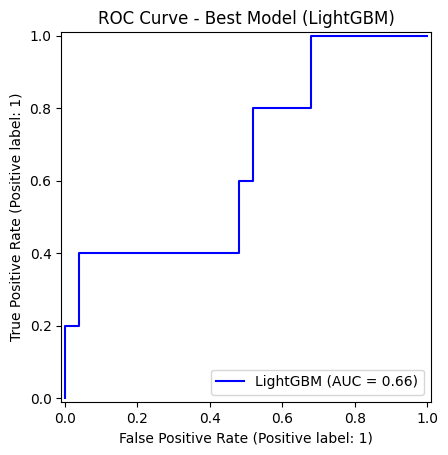

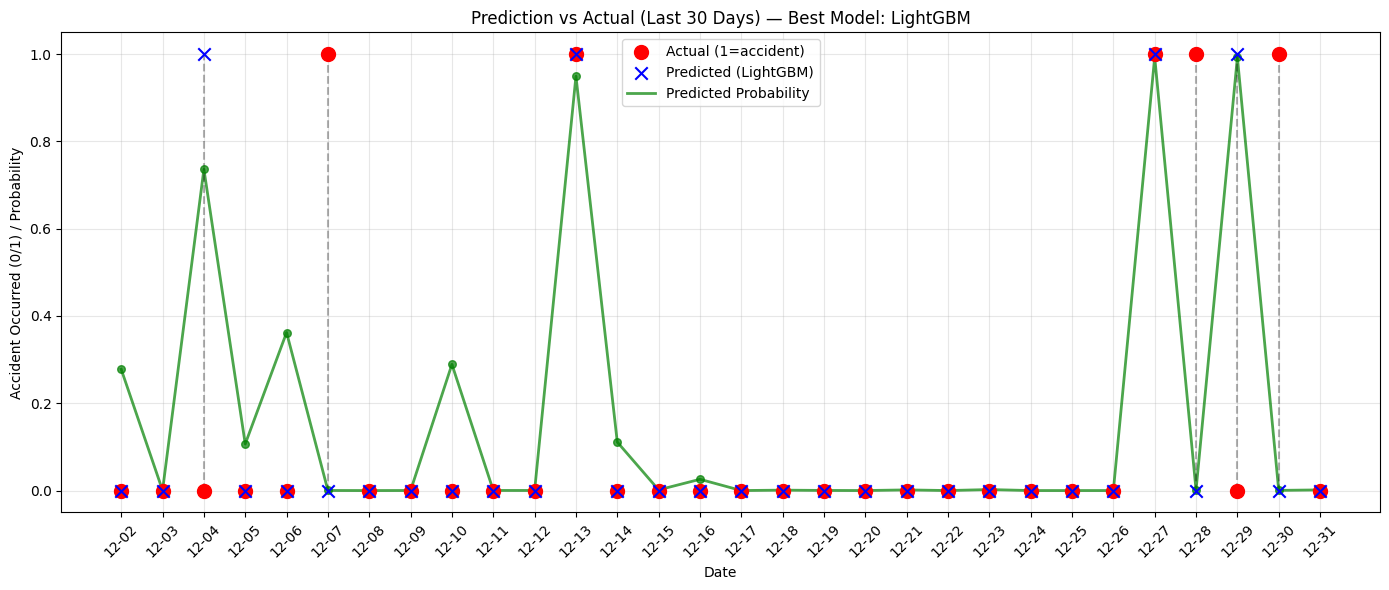

In [15]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, f1_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# ===============================
# 1) Load & prepare data
# ===============================
df = pd.read_csv("clean_data.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")

# target = binary (มีเหตุ >=1)
df["target"] = (df["เกิดเหตุ"] > 0).astype(int)

# drop datetime ออกจาก feature
features = [c for c in df.columns if c not in ["datetime", "เกิดเหตุ", "target"]]

# split train/test
train = df.iloc[:-30]
test = df.iloc[-30:]

X_train = train[features]
y_train = train["target"]
X_test = test[features]
y_test = test["target"]

# oversample (SMOTE)
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

# ===============================
# 2) Helper for evaluation
# ===============================
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test, scale=False):
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"\n==== {name} ====")
    print(classification_report(y_test, y_pred, digits=2))
    auc = roc_auc_score(y_test, y_prob)
    rmse = mean_squared_error(y_test, y_prob, squared=False)
    f1 = f1_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    print("ROC-AUC:", round(auc, 4))
    print("RMSE:", round(rmse, 4))

    # เก็บผลลัพธ์ไว้เปรียบเทียบ
    results[name] = {
        "auc": auc, "rmse": rmse, "f1": f1, "recall": rec,
        "model": model, "y_prob": y_prob, "y_pred": y_pred
    }
    return model, y_prob, y_pred

# ===============================
# 3) Train & Evaluate Models
# ===============================
log_clf = LogisticRegression(max_iter=300, class_weight="balanced", random_state=42)
evaluate_model("Logistic Regression", log_clf, X_res, y_res, X_test, y_test, scale=True)

rf_clf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
evaluate_model("Random Forest", rf_clf, X_res, y_res, X_test, y_test)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    scale_pos_weight=sum(y_res == 0) / sum(y_res == 1),
    eval_metric="logloss", use_label_encoder=False, random_state=42
)
evaluate_model("XGBoost", xgb_clf, X_res, y_res, X_test, y_test)

lgb_clf = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.1, class_weight="balanced", random_state=42
)
evaluate_model("LightGBM", lgb_clf, X_res, y_res, X_test, y_test)

# ===============================
# 4) เลือกโมเดลที่ดีที่สุด
# ===============================
df_results = pd.DataFrame(results).T
print("\n📊 Summary Results:")
print(df_results[["rmse", "f1", "recall", "auc"]])

best_rmse_model = df_results["rmse"].idxmin()
best_f1_model = df_results["f1"].idxmax()
best_recall_model = df_results["recall"].idxmax()

print(f"\n🏆 Best RMSE: {best_rmse_model}")
print(f"🏆 Best F1-score: {best_f1_model}")
print(f"🏆 Best Recall: {best_recall_model}")

# ===============================
# 5) พล็อต ROC ของโมเดลที่ดีที่สุดตาม F1
# ===============================
best_model_name = best_f1_model
best_model_info = results[best_model_name]

plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, best_model_info["y_prob"], name=best_model_name, color="blue")
plt.title(f"ROC Curve - Best Model ({best_model_name})")
plt.show()

# ===============================
# 6) พล็อต Predicted vs Actual (30 วันสุดท้าย) + Probability
# ===============================
dates = test["datetime"].dt.strftime("%m-%d")
x_pos = range(len(dates))

plt.figure(figsize=(14,6))

# Actual
plt.scatter(x_pos, y_test, color="red", label="Actual (1=accident)", marker="o", s=100, zorder=5)

# Predicted (binary)
plt.scatter(x_pos, best_model_info["y_pred"], color="blue", label=f"Predicted ({best_model_name})", marker="x", s=80, zorder=5)

# Probability (continuous)
plt.plot(x_pos, best_model_info["y_prob"], color="green", linestyle="-", linewidth=2, alpha=0.7, label="Predicted Probability")
plt.scatter(x_pos, best_model_info["y_prob"], color="green", s=30, alpha=0.7, zorder=4)

# เชื่อมเส้นระหว่าง actual กับ predicted binary
for i in range(len(dates)):
    plt.plot([x_pos[i], x_pos[i]], [y_test.iloc[i], best_model_info["y_pred"][i]], 'k--', alpha=0.3)

plt.xticks(x_pos, dates, rotation=45)
plt.xlabel("Date")
plt.ylabel("Accident Occurred (0/1) / Probability")
plt.title(f"Prediction vs Actual (Last 30 Days) — Best Model: {best_model_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)  # ปรับให้เห็น probability ชัด
plt.tight_layout()
plt.show()

Train size: 336, Test size: 30
Train event rate: 16.37%
Test event rate: 16.67%
Train sequences: (329, 7, 9)
Test sequences: (30, 7, 9)
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_8 (LSTM)               (None, 7, 64)             18944     
                                                                 
 dropout_8 (Dropout)         (None, 7, 64)             0         
                                                                 
 lstm_9 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_9 (Dropout)         (None, 32)                0         
                                                                 
 dense_8 (Dense)             (None, 16)                528       
                                                                 
 dense_9 (Dense)             (None, 1)            

<Figure size 800x600 with 0 Axes>

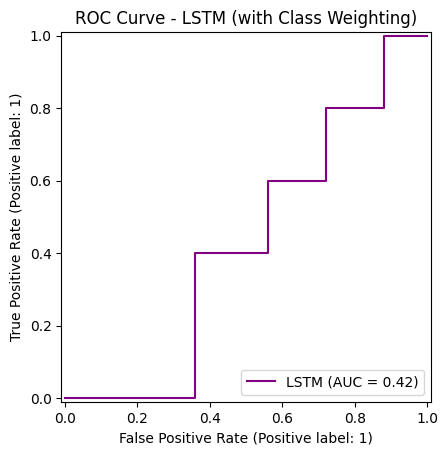

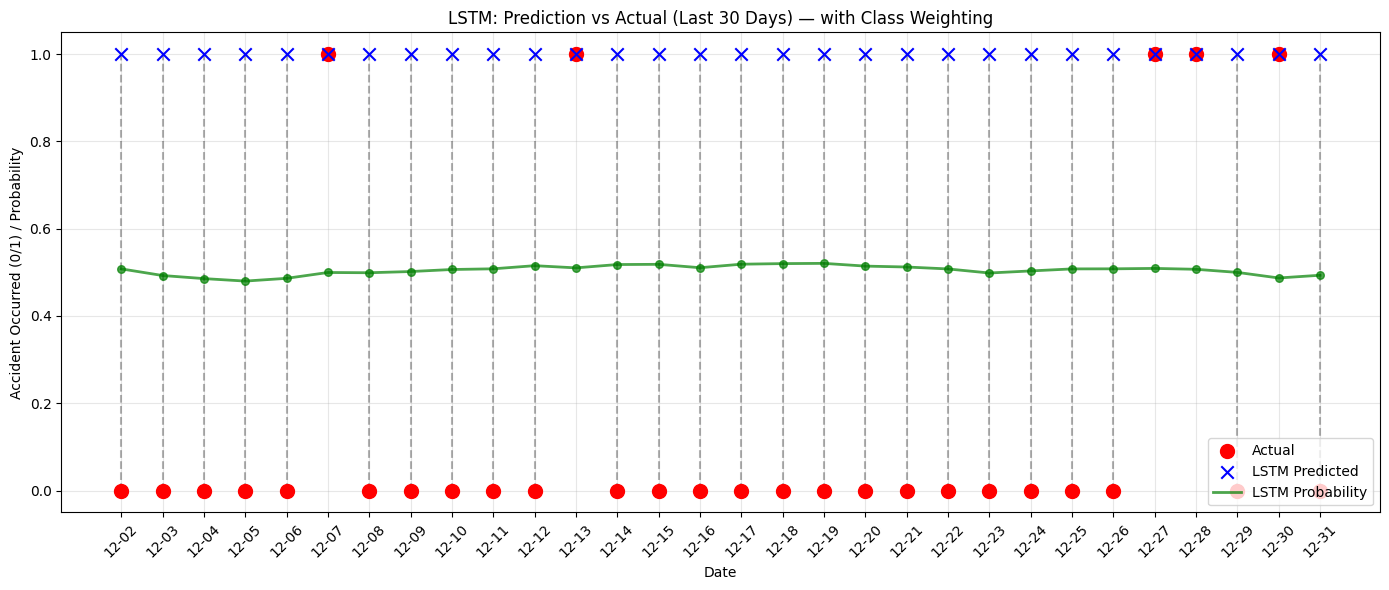

In [ ]:
# ===============================
# LSTM for Accident Prediction (with Class Weighting)
# ===============================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# -------------------------------
# 1) Load & prepare data
# -------------------------------
df = pd.read_csv("clean_data.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
df["target"] = (df["เกิดเหตุ"] > 0).astype(int)

features = [c for c in df.columns if c not in ["datetime", "เกิดเหตุ", "target"]]

# Split: last 30 days as test
train = df.iloc[:-30]
test = df.iloc[-30:]

print(f"Train size: {len(train)}, Test size: {len(test)}")
print(f"Train event rate: {train['target'].mean():.2%}")
print(f"Test event rate: {test['target'].mean():.2%}")

# -------------------------------
# 2) Create sequences with proper time alignment
# -------------------------------
LOOKBACK = 7

def create_sequences(data, features, target_col, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[features].iloc[i-lookback:i].values)
        y.append(data[target_col].iloc[i])
    return np.array(X), np.array(y)

# Train sequences
X_train_seq, y_train_seq = create_sequences(train, features, "target", LOOKBACK)

# Test sequences (with context from end of train)
test_input = pd.concat([train.iloc[-LOOKBACK:], test], ignore_index=True)
X_test_seq, y_test_seq = create_sequences(test_input, features, "target", LOOKBACK)

# Validate
assert len(y_test_seq) == len(test), "Test sequence length mismatch!"
print(f"Train sequences: {X_train_seq.shape}")
print(f"Test sequences: {X_test_seq.shape}")

# -------------------------------
# 3) Feature scaling
# -------------------------------
scaler = StandardScaler()

X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat)
X_train_seq = X_train_scaled.reshape(X_train_seq.shape)

X_test_flat = X_test_seq.reshape(-1, X_test_seq.shape[-1])
X_test_scaled = scaler.transform(X_test_flat)
X_test_seq = X_test_scaled.reshape(X_test_seq.shape)

# -------------------------------
# 4) Build LSTM model
# -------------------------------
n_features = X_train_seq.shape[2]

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(LOOKBACK, n_features)),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

# -------------------------------
# 5) Compute class weights & Train
# -------------------------------
classes = np.unique(y_train_seq)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train_seq
)
class_weight_dict = dict(zip(classes, class_weights))
print("✅ Class weights:", class_weight_dict)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    class_weight=class_weight_dict,  # 👈 สำคัญมาก!
    verbose=1
)

# -------------------------------
# 6) Evaluate
# -------------------------------
y_pred_prob = model.predict(X_test_seq).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print("\n==== LSTM (with Class Weighting) ====")
print(classification_report(y_test_seq, y_pred, digits=2))
auc = roc_auc_score(y_test_seq, y_pred_prob)
f1 = f1_score(y_test_seq, y_pred)
rec = recall_score(y_test_seq, y_pred)
rmse = np.sqrt(np.mean((y_test_seq - y_pred_prob) ** 2))

print("ROC-AUC:", round(auc, 4))
print("RMSE:", round(rmse, 4))
print("F1-score:", round(f1, 4))
print("Recall (Sensitivity):", round(rec, 4))

# -------------------------------
# 7) Plot ROC Curve
# -------------------------------
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test_seq, y_pred_prob, name="LSTM", color="purple")
plt.title("ROC Curve - LSTM (with Class Weighting)")
plt.show()

# -------------------------------
# 8) Plot Prediction vs Actual (Last 30 Days)
# -------------------------------
dates = test["datetime"].dt.strftime("%m-%d")
n_preds = len(y_test_seq)

assert len(dates) == n_preds, f"Date length ({len(dates)}) != prediction length ({n_preds})"

x_pos = range(n_preds)

plt.figure(figsize=(14,6))

# Actual
plt.scatter(x_pos, y_test_seq, color="red", label="Actual", marker="o", s=100, zorder=5)

# Predicted binary
plt.scatter(x_pos, y_pred, color="blue", label="LSTM Predicted", marker="x", s=80, zorder=5)

# Predicted probability
plt.plot(x_pos, y_pred_prob, color="green", linestyle="-", linewidth=2, alpha=0.7, label="LSTM Probability")
plt.scatter(x_pos, y_pred_prob, color="green", s=30, alpha=0.7, zorder=4)

# Connect lines
for i in range(n_preds):
    plt.plot([x_pos[i], x_pos[i]], [y_test_seq[i], y_pred[i]], 'k--', alpha=0.3)

plt.xticks(x_pos, dates, rotation=45)
plt.xlabel("Date")
plt.ylabel("Accident Occurred (0/1) / Probability")
plt.title("LSTM: Prediction vs Actual (Last 30 Days) — with Class Weighting")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

# -------------------------------
# Optional: Save model
# -------------------------------
# model.save("lstm_accident_model_weighted.h5")

📊 Dataset Overview:
Total days: 366
Train: 336 days | Test: 30 days
Train event rate: 16.37%
Test event rate: 16.67%


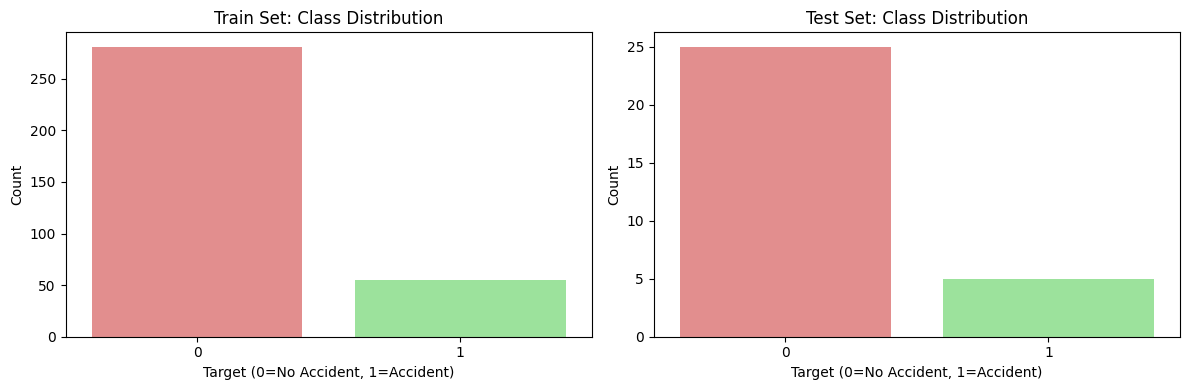


⚖️ Class Weights (for reference): {0: 0.597864768683274, 1: 3.0545454545454547}

🧮 Sequence shapes: Train (329, 7, 9), Test (30, 7, 9)

🧠 Model Summary:
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_11 (LSTM)              (None, 32)                5376      
                                                                 
 dense_11 (Dense)            (None, 1)                 33        
                                                                 
Total params: 5,409
Trainable params: 5,409
Non-trainable params: 0
_________________________________________________________________
None
Epoch 1/100
17/17 [==============================] - 4s 48ms/step - loss: 0.0515 - accuracy: 0.5475 - val_loss: 0.0568 - val_accuracy: 0.3636
Epoch 2/100
17/17 [==============================] - 0s 8ms/step - loss: 0.0490 - accuracy: 0.6464 - val_loss: 0.0579 - val_accuracy: 0.3485
Epoch 

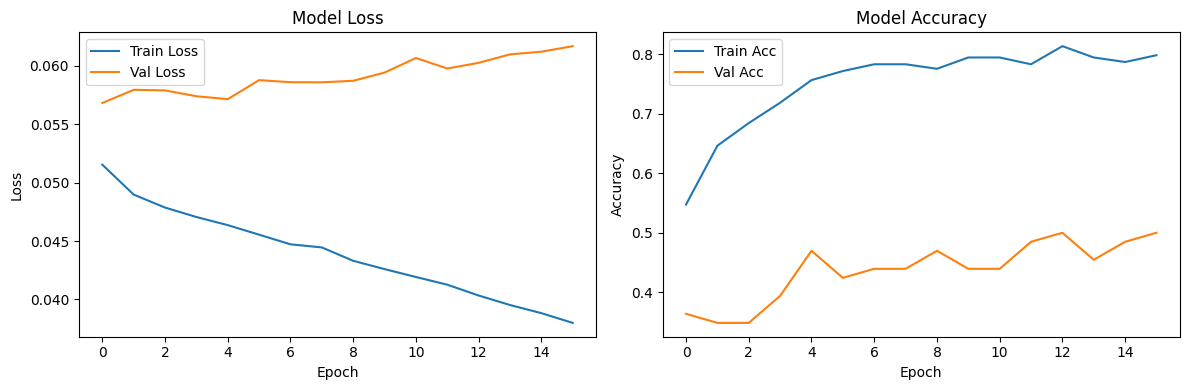

1/1 [==============================] - 1s 536ms/step

🔍 Evaluation (Threshold = 0.5):
              precision    recall  f1-score   support

           0       0.93      0.56      0.70        25
           1       0.27      0.80      0.40         5

    accuracy                           0.60        30
   macro avg       0.60      0.68      0.55        30
weighted avg       0.82      0.60      0.65        30

ROC-AUC: 0.6800
Recall: 0.8000


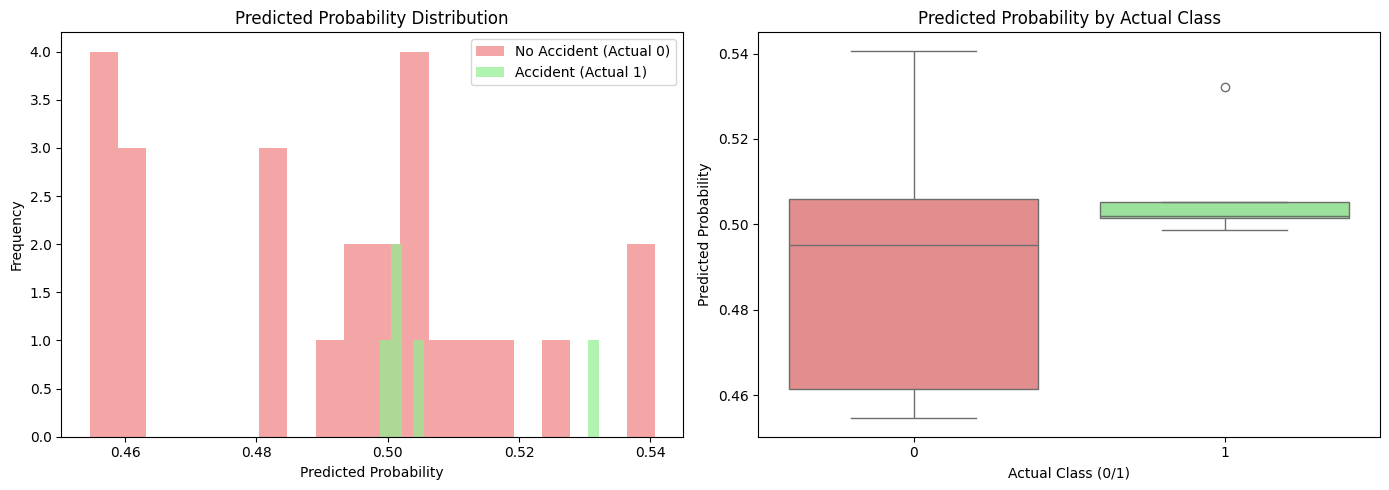


🔍 Evaluation (Threshold = 0.3):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        25
           1       0.17      1.00      0.29         5

    accuracy                           0.17        30
   macro avg       0.08      0.50      0.14        30
weighted avg       0.03      0.17      0.05        30

Recall: 1.0000
Precision: 0.1667


<Figure size 800x600 with 0 Axes>

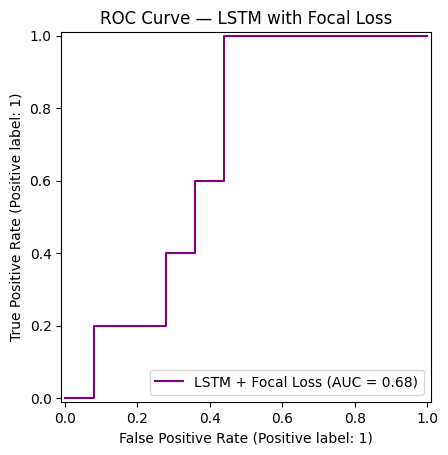

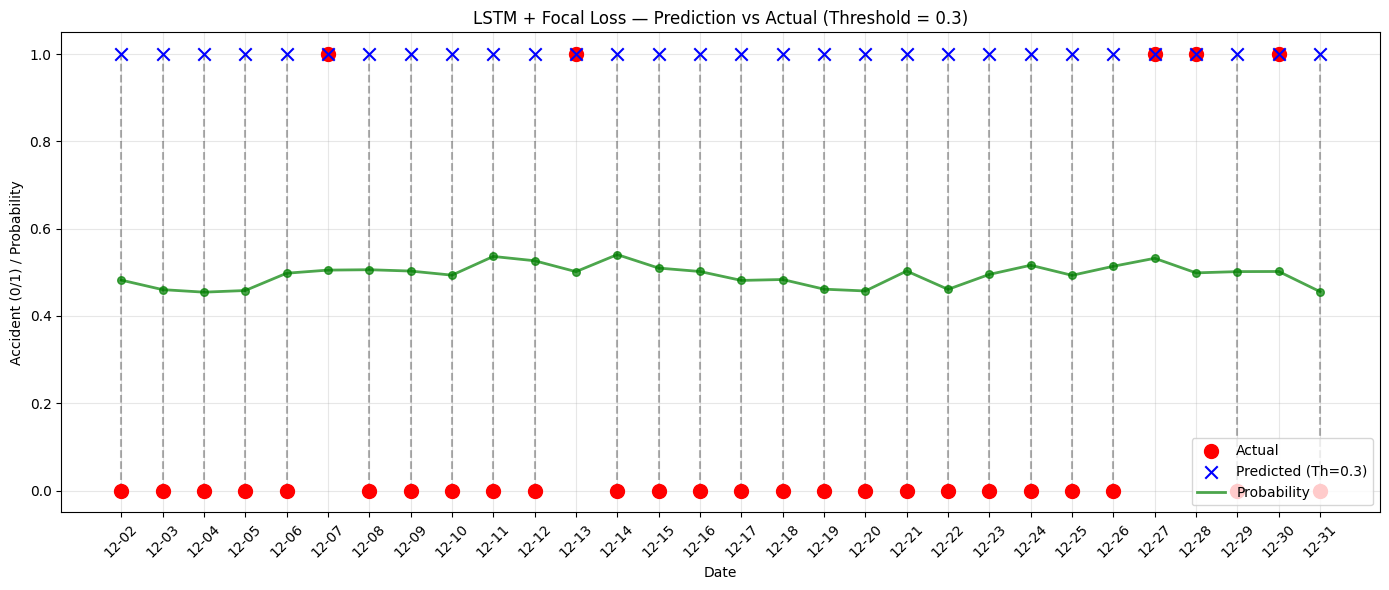

In [23]:
# ===============================
# LSTM with Focal Loss for Imbalanced Time-Series Classification
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, f1_score, recall_score, precision_score
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import RocCurveDisplay

# -------------------------------
# 1) Load & prepare data
# -------------------------------
df = pd.read_csv("clean_data.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
df["target"] = (df["เกิดเหตุ"] > 0).astype(int)

features = [c for c in df.columns if c not in ["datetime", "เกิดเหตุ", "target"]]

train = df.iloc[:-30]
test = df.iloc[-30:]

print(f"📊 Dataset Overview:")
print(f"Total days: {len(df)}")
print(f"Train: {len(train)} days | Test: {len(test)} days")
print(f"Train event rate: {train['target'].mean():.2%}")
print(f"Test event rate: {test['target'].mean():.2%}")

# -------------------------------
# 2) Plot Class Distribution
# -------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.countplot(x=train['target'], palette=['lightcoral', 'lightgreen'])
plt.title('Train Set: Class Distribution')
plt.xlabel('Target (0=No Accident, 1=Accident)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=test['target'], palette=['lightcoral', 'lightgreen'])
plt.title('Test Set: Class Distribution')
plt.xlabel('Target (0=No Accident, 1=Accident)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# -------------------------------
# 3) Show Class Weights (for reference)
# -------------------------------
if train['target'].sum() > 0:
    classes = np.unique(train['target'])
    class_weights = compute_class_weight('balanced', classes=classes, y=train['target'])
    class_weight_dict = dict(zip(classes, class_weights))
    print(f"\n⚖️ Class Weights (for reference): {class_weight_dict}")
else:
    print("\n⚠️ No accidents in train set!")

# -------------------------------
# 4) Create sequences
# -------------------------------
LOOKBACK = 7

def create_sequences(data, features, target_col, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[features].iloc[i-lookback:i].values)
        y.append(data[target_col].iloc[i])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = create_sequences(train, features, "target", LOOKBACK)
test_input = pd.concat([train.iloc[-LOOKBACK:], test], ignore_index=True)
X_test_seq, y_test_seq = create_sequences(test_input, features, "target", LOOKBACK)

assert len(y_test_seq) == len(test), "Test sequence length mismatch!"
print(f"\n🧮 Sequence shapes: Train {X_train_seq.shape}, Test {X_test_seq.shape}")

# -------------------------------
# 5) Scale features
# -------------------------------
scaler = StandardScaler()
X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat)
X_train_seq = X_train_scaled.reshape(X_train_seq.shape)

X_test_flat = X_test_seq.reshape(-1, X_test_seq.shape[-1])
X_test_scaled = scaler.transform(X_test_flat)
X_test_seq = X_test_scaled.reshape(X_test_seq.shape)

# -------------------------------
# 6) Define Focal Loss
# -------------------------------
def focal_loss(gamma=2., alpha=0.75):
    """
    Focal Loss for imbalanced classification.
    - alpha: weight for positive class (1 = accident). Increase to focus more on accidents.
    - gamma: focusing parameter. Higher = harder examples get more weight.
    """
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        focal_loss_val = -alpha_t * tf.pow(1. - pt, gamma) * tf.math.log(pt)
        return tf.reduce_mean(focal_loss_val)
    return loss

# -------------------------------
# 7) Build & Train LSTM with Focal Loss
# -------------------------------
n_features = X_train_seq.shape[2]

model = Sequential([
    LSTM(32, input_shape=(LOOKBACK, n_features)),  # ลด complexity
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.80),  # เน้น class 1 มากขึ้น
    metrics=['accuracy']
)

print("\n🧠 Model Summary:")
print(model.summary())

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

# -------------------------------
# 8) Plot Training History
# -------------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# -------------------------------
# 9) Evaluate with default threshold (0.5)
# -------------------------------
y_pred_prob = model.predict(X_test_seq).flatten()
y_pred_default = (y_pred_prob > 0.5).astype(int)

print("\n🔍 Evaluation (Threshold = 0.5):")
print(classification_report(y_test_seq, y_pred_default, digits=2))
print(f"ROC-AUC: {roc_auc_score(y_test_seq, y_pred_prob):.4f}")
print(f"Recall: {recall_score(y_test_seq, y_pred_default):.4f}")

# -------------------------------
# 10) Analyze Predicted Probabilities
# -------------------------------
plt.figure(figsize=(14, 5))

# Distribution of probabilities
plt.subplot(1, 2, 1)
plt.hist(y_pred_prob[y_test_seq == 0], bins=20, alpha=0.7, label='No Accident (Actual 0)', color='lightcoral')
plt.hist(y_pred_prob[y_test_seq == 1], bins=20, alpha=0.7, label='Accident (Actual 1)', color='lightgreen')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.title('Predicted Probability Distribution')
plt.legend()

# Boxplot by actual class
plt.subplot(1, 2, 2)
prob_df = pd.DataFrame({'prob': y_pred_prob, 'actual': y_test_seq})
sns.boxplot(data=prob_df, x='actual', y='prob', palette=['lightcoral', 'lightgreen'])
plt.title('Predicted Probability by Actual Class')
plt.xlabel('Actual Class (0/1)')
plt.ylabel('Predicted Probability')

plt.tight_layout()
plt.show()

# -------------------------------
# 11) Try adjusted threshold (e.g., 0.3)
# -------------------------------
best_threshold = 0.3
y_pred_adj = (y_pred_prob > best_threshold).astype(int)

print(f"\n🔍 Evaluation (Threshold = {best_threshold}):")
print(classification_report(y_test_seq, y_pred_adj, digits=2))
print(f"Recall: {recall_score(y_test_seq, y_pred_adj):.4f}")
print(f"Precision: {precision_score(y_test_seq, y_pred_adj):.4f}")

# -------------------------------
# 12) Final ROC Curve
# -------------------------------
plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test_seq, y_pred_prob, name="LSTM + Focal Loss", color="purple")
plt.title("ROC Curve — LSTM with Focal Loss")
plt.show()

# -------------------------------
# 13) Final Prediction vs Actual Plot
# -------------------------------
dates = test["datetime"].dt.strftime("%m-%d")
n_preds = len(y_test_seq)

plt.figure(figsize=(14,6))
x_pos = range(n_preds)

plt.scatter(x_pos, y_test_seq, color="red", label="Actual", marker="o", s=100, zorder=5)
plt.scatter(x_pos, y_pred_adj, color="blue", label=f"Predicted (Th={best_threshold})", marker="x", s=80, zorder=5)
plt.plot(x_pos, y_pred_prob, color="green", linestyle="-", linewidth=2, alpha=0.7, label="Probability")
plt.scatter(x_pos, y_pred_prob, color="green", s=30, alpha=0.7, zorder=4)

for i in range(n_preds):
    plt.plot([x_pos[i], x_pos[i]], [y_test_seq[i], y_pred_adj[i]], 'k--', alpha=0.3)

plt.xticks(x_pos, dates, rotation=45)
plt.xlabel("Date")
plt.ylabel("Accident (0/1) / Probability")
plt.title(f"LSTM + Focal Loss — Prediction vs Actual (Threshold = {best_threshold})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Train size: 336, Test size: 30


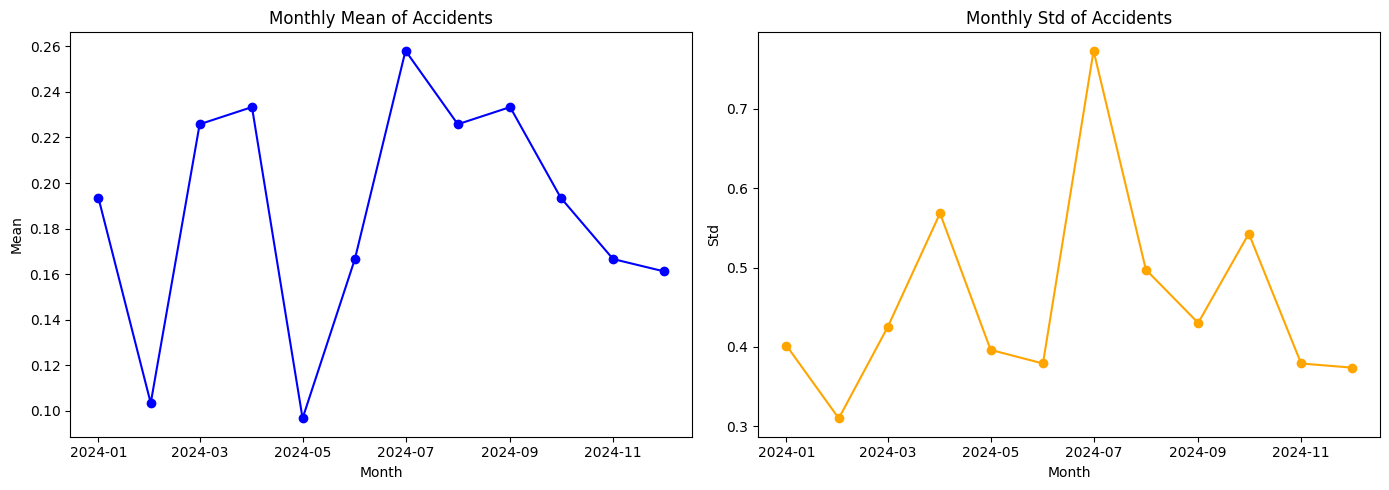


🔍 Tuning SARIMAX...
SARIMAX: Using d=0
Best SARIMAX: order=(1, 0, 2), seasonal_order=(0, 0, 1, 30)

🔍 Tuning LightGBM...
Best LightGBM: lag=[3], rolling=[3], F1=0.5455

🔍 Training LSTM...
1/1 [==============================] - 1s 504ms/step

📊 Comparison Results:
      Model Threshold    RMSE      F1  Precision  Recall
0   SARIMAX       0.3  0.3871  0.0000     0.0000     0.0
1   SARIMAX       0.5  0.3871  0.0000     0.0000     0.0
2  LightGBM       0.3  0.3421  0.5455     0.5000     0.6
3  LightGBM       0.5  0.3421  0.5455     0.5000     0.6
4      LSTM       0.3  0.5010  0.2857     0.1667     1.0
5      LSTM       0.5  0.5010  0.3810     0.2500     0.8

🏆 Best Model: LightGBM (Threshold=0.3) with F1=0.5455


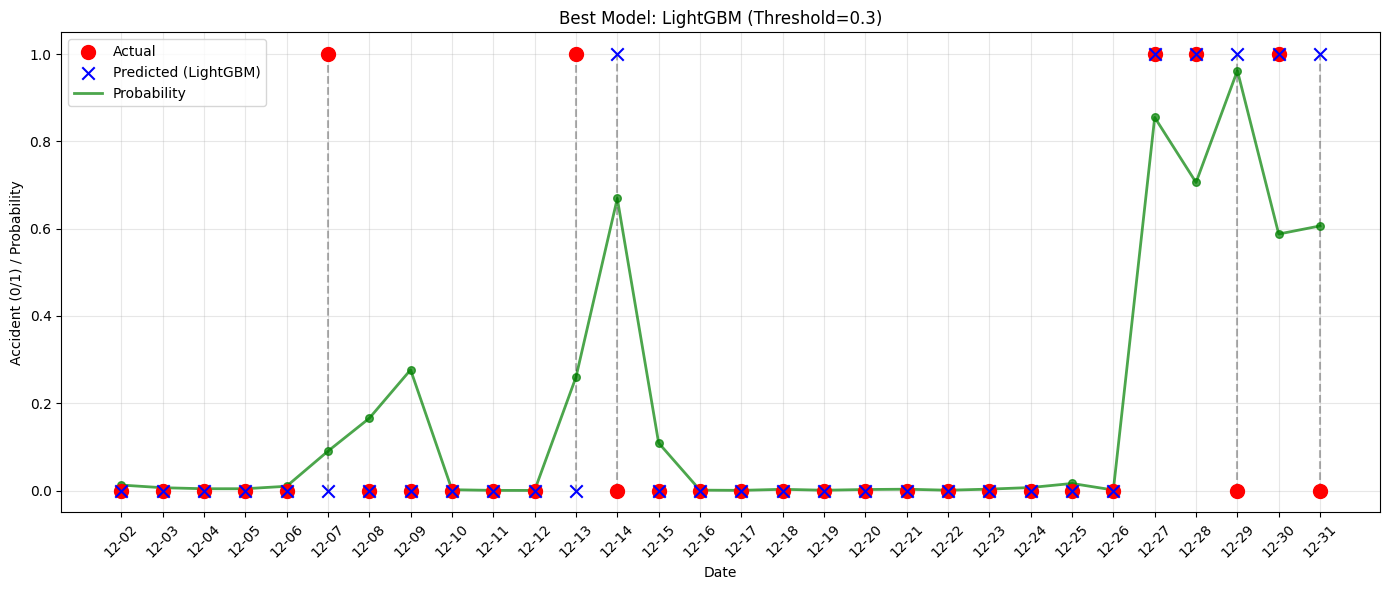

In [24]:
# ===============================
# Model Comparison: SARIMAX vs LightGBM vs LSTM
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings("ignore")

# TensorFlow for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------
# 1) Load & prepare data
# -------------------------------
df = pd.read_csv("clean_data.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
df["target"] = (df["เกิดเหตุ"] > 0).astype(int)

features = [c for c in df.columns if c not in ["datetime", "เกิดเหตุ", "target"]]

# Split: last 30 days as test
train_full = df.iloc[:-30].copy()
test = df.iloc[-30:].copy()

print(f"Train size: {len(train_full)}, Test size: {len(test)}")

# -------------------------------
# 2) Monthly Mean & Std Visualization
# -------------------------------
df_monthly = df.copy()
df_monthly['month'] = df_monthly['datetime'].dt.to_period('M')
monthly_stats = df_monthly.groupby('month')['เกิดเหตุ'].agg(['mean', 'std']).reset_index()
monthly_stats['month'] = monthly_stats['month'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(monthly_stats['month'], monthly_stats['mean'], marker='o', color='blue')
plt.title('Monthly Mean of Accidents')
plt.xlabel('Month')
plt.ylabel('Mean')

plt.subplot(1, 2, 2)
plt.plot(monthly_stats['month'], monthly_stats['std'], marker='o', color='orange')
plt.title('Monthly Std of Accidents')
plt.xlabel('Month')
plt.ylabel('Std')

plt.tight_layout()
plt.show()

# -------------------------------
# 3) Helper: Evaluate function
# -------------------------------
def evaluate(y_true, y_pred, y_prob=None, model_name="", threshold_note=""):
    rmse = mean_squared_error(y_true, y_prob if y_prob is not None else y_pred, squared=False)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Threshold": threshold_note,
        "RMSE": rmse,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "y_pred": y_pred.copy(),
        "y_prob": y_prob.copy() if y_prob is not None else y_pred.copy()
    }

# -------------------------------
# 4) SARIMAX with Auto Order Selection
# -------------------------------
print("\n🔍 Tuning SARIMAX...")

# Use only 'เกิดเหตุ' as time series
ts_train = train_full.set_index('datetime')['เกิดเหตุ']
ts_test = test.set_index('datetime')['เกิดเหตุ']

# Check stationarity
def is_stationary(series):
    result = adfuller(series.dropna())
    return result[1] < 0.05  # p-value < 0.05 → stationary

# Difference if needed
d = 0
ts_diff = ts_train.copy()
while not is_stationary(ts_diff) and d < 2:
    d += 1
    ts_diff = ts_diff.diff().dropna()

print(f"SARIMAX: Using d={d}")

# Grid search for best (p,q) and seasonal_order
best_aic = np.inf
best_order = None
best_seasonal_order = None

# Non-seasonal
p_vals = range(0, 3)
q_vals = range(0, 3)

# Seasonal (try monthly seasonality)
seasonal_periods = [7, 12, 30]  # weekly, monthly-ish, monthly
for s in seasonal_periods:
    for P in range(0, 2):
        for Q in range(0, 2):
            for p in p_vals:
                for q in q_vals:
                    try:
                        order = (p, d, q)
                        seasonal_order = (P, d, Q, s)
                        model = SARIMAX(
                            ts_train,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        fitted = model.fit(disp=False)
                        if fitted.aic < best_aic:
                            best_aic = fitted.aic
                            best_order = order
                            best_seasonal_order = seasonal_order
                    except:
                        continue

print(f"Best SARIMAX: order={best_order}, seasonal_order={best_seasonal_order}")

# Final SARIMAX model
sarimax_model = SARIMAX(
    ts_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fitted = sarimax_model.fit(disp=False)

# Forecast
sarimax_pred = sarimax_fitted.forecast(steps=len(ts_test))
sarimax_pred_binary_05 = (sarimax_pred > 0.5).astype(int)
sarimax_pred_binary_03 = (sarimax_pred > 0.3).astype(int)

# Store results
sarimax_results = {
    "0.5": evaluate(test["target"], sarimax_pred_binary_05, sarimax_pred, "SARIMAX", "0.5"),
    "0.3": evaluate(test["target"], sarimax_pred_binary_03, sarimax_pred, "SARIMAX", "0.3")
}

# -------------------------------
# 5) LightGBM with Auto Lag/Rolling Selection
# -------------------------------
print("\n🔍 Tuning LightGBM...")

def create_lgb_features(df, lags, rollings):
    df_feat = df.copy()
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['target'].shift(lag)
    for win in rollings:
        df_feat[f'roll_mean_{win}'] = df_feat['target'].rolling(win).mean()
        df_feat[f'roll_std_{win}'] = df_feat['target'].rolling(win).std()
    return df_feat

# Candidate windows
candidate_windows = [1, 3, 7, 14, 30]
best_f1 = -1
best_lag = None
best_roll = None
best_lgb_model = None
best_lgb_pred_prob = None

# Simple grid: try each window as both lag and rolling
for win in candidate_windows:
    lags = [win]
    rollings = [win]
    
    # Create features
    df_lgb = create_lgb_features(train_full, lags, rollings)
    df_lgb = df_lgb.dropna()
    
    if len(df_lgb) < 10:
        continue
        
    X_train = df_lgb.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_train = df_lgb["target"]
    
    # Train LightGBM
    model = lgb.LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    # Prepare test set
    df_test_full = pd.concat([train_full.iloc[-max(candidate_windows):], test], ignore_index=True)
    df_test_feat = create_lgb_features(df_test_full, lags, rollings)
    df_test_final = df_test_feat.iloc[-len(test):].dropna()
    
    if len(df_test_final) != len(test):
        continue
        
    X_test = df_test_final.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(test["target"].iloc[:len(y_pred)], y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_lag = lags
        best_roll = rollings
        best_lgb_model = model
        best_lgb_pred_prob = y_prob

print(f"Best LightGBM: lag={best_lag}, rolling={best_roll}, F1={best_f1:.4f}")

# Final predictions
lgb_pred_binary_05 = (best_lgb_pred_prob > 0.5).astype(int)
lgb_pred_binary_03 = (best_lgb_pred_prob > 0.3).astype(int)

lgb_results = {
    "0.5": evaluate(test["target"], lgb_pred_binary_05, best_lgb_pred_prob, "LightGBM", "0.5"),
    "0.3": evaluate(test["target"], lgb_pred_binary_03, best_lgb_pred_prob, "LightGBM", "0.3")
}

# -------------------------------
# 6) LSTM with Focal Loss
# -------------------------------
print("\n🔍 Training LSTM...")

LOOKBACK = 7
def create_sequences(data, features, target_col, lookback):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[features].iloc[i-lookback:i].values)
        y.append(data[target_col].iloc[i])
    return np.array(X), np.array(y)

# Sequences
X_train_seq, y_train_seq = create_sequences(train_full, features, "target", LOOKBACK)
test_input = pd.concat([train_full.iloc[-LOOKBACK:], test], ignore_index=True)
X_test_seq, y_test_seq = create_sequences(test_input, features, "target", LOOKBACK)

# Scale
scaler = StandardScaler()
X_train_flat = X_train_seq.reshape(-1, X_train_seq.shape[-1])
X_train_scaled = scaler.fit_transform(X_train_flat)
X_train_seq = X_train_scaled.reshape(X_train_seq.shape)

X_test_flat = X_test_seq.reshape(-1, X_test_seq.shape[-1])
X_test_scaled = scaler.transform(X_test_flat)
X_test_seq = X_test_scaled.reshape(X_test_seq.shape)

# Focal Loss
def focal_loss(gamma=2., alpha=0.8):
    def loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        return -tf.reduce_mean(alpha_t * tf.pow(1. - pt, gamma) * tf.math.log(pt))
    return loss

# Model
n_features = X_train_seq.shape[2]
lstm_model = Sequential([
    LSTM(32, input_shape=(LOOKBACK, n_features)),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])
lstm_model.compile(optimizer=Adam(0.001), loss=focal_loss(), metrics=['accuracy'])

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

# Predict
lstm_pred_prob = lstm_model.predict(X_test_seq).flatten()
lstm_pred_05 = (lstm_pred_prob > 0.5).astype(int)
lstm_pred_03 = (lstm_pred_prob > 0.3).astype(int)

lstm_results = {
    "0.5": evaluate(y_test_seq, lstm_pred_05, lstm_pred_prob, "LSTM", "0.5"),
    "0.3": evaluate(y_test_seq, lstm_pred_03, lstm_pred_prob, "LSTM", "0.3")
}

# -------------------------------
# 7) Compare All Results
# -------------------------------
all_results = []
for res in [sarimax_results, lgb_results, lstm_results]:
    for thresh in ["0.3", "0.5"]:
        all_results.append(res[thresh])

results_df = pd.DataFrame(all_results)
print("\n📊 Comparison Results:")
print(results_df[["Model", "Threshold", "RMSE", "F1", "Precision", "Recall"]].round(4))

# Find best model by F1
best_row = results_df.loc[results_df["F1"].idxmax()]
print(f"\n🏆 Best Model: {best_row['Model']} (Threshold={best_row['Threshold']}) with F1={best_row['F1']:.4f}")

# -------------------------------
# 8) Plot Best Model: Actual vs Predicted + Probability
# -------------------------------
dates = test["datetime"].dt.strftime("%m-%d")
y_true = test["target"] if best_row["Model"] != "LSTM" else y_test_seq
y_pred = best_row["y_pred"]
y_prob = best_row["y_prob"]

plt.figure(figsize=(14,6))
x_pos = range(len(dates))

plt.scatter(x_pos, y_true, color="red", label="Actual", marker="o", s=100, zorder=5)
plt.scatter(x_pos, y_pred, color="blue", label=f"Predicted ({best_row['Model']})", marker="x", s=80, zorder=5)
plt.plot(x_pos, y_prob, color="green", linestyle="-", linewidth=2, alpha=0.7, label="Probability")
plt.scatter(x_pos, y_prob, color="green", s=30, alpha=0.7, zorder=4)

for i in range(len(dates)):
    plt.plot([x_pos[i], x_pos[i]], [y_true.iloc[i] if hasattr(y_true, 'iloc') else y_true[i], y_pred[i]], 'k--', alpha=0.3)

plt.xticks(x_pos, dates, rotation=45)
plt.xlabel("Date")
plt.ylabel("Accident (0/1) / Probability")
plt.title(f"Best Model: {best_row['Model']} (Threshold={best_row['Threshold']})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

Train size: 701, Test size: 30


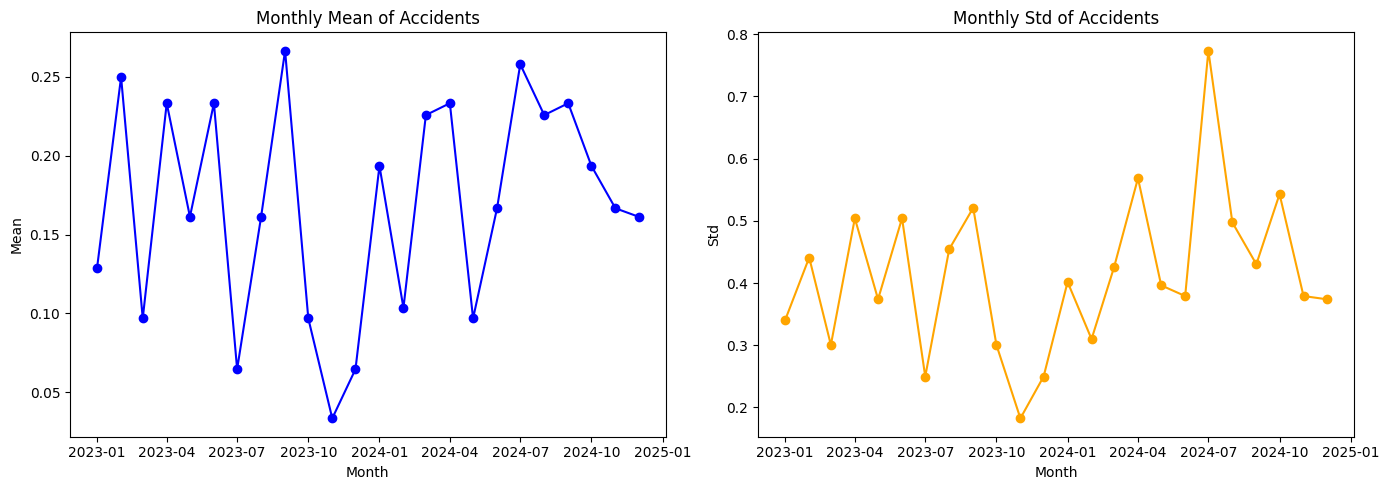


🔍 Tuning SARIMAX with exogenous variables...
SARIMAX: Using d=0
Best SARIMAX: order=(0, 0, 2), seasonal_order=(0, 0, 1, 30)

🔍 Tuning LightGBM...
Best LightGBM: lag=[3], rolling=[3], F1=0.6000

🔍 Tuning XGBoost...
Best XGBoost: lag=[3], rolling=[3], F1=0.4444

📊 Comparison Results:
      Model Threshold    RMSE      F1  Precision  Recall
0   SARIMAX       0.3  0.3853  0.0000     0.0000     0.0
1   SARIMAX       0.5  0.3853  0.0000     0.0000     0.0
2  LightGBM       0.3  0.3372  0.6154     0.5000     0.8
3  LightGBM       0.5  0.3372  0.6000     0.6000     0.6
4   XGBoost       0.3  0.3188  0.7273     0.6667     0.8
5   XGBoost       0.5  0.3188  0.4444     0.5000     0.4

🏆 Best Model: XGBoost (Threshold=0.3) with F1=0.7273


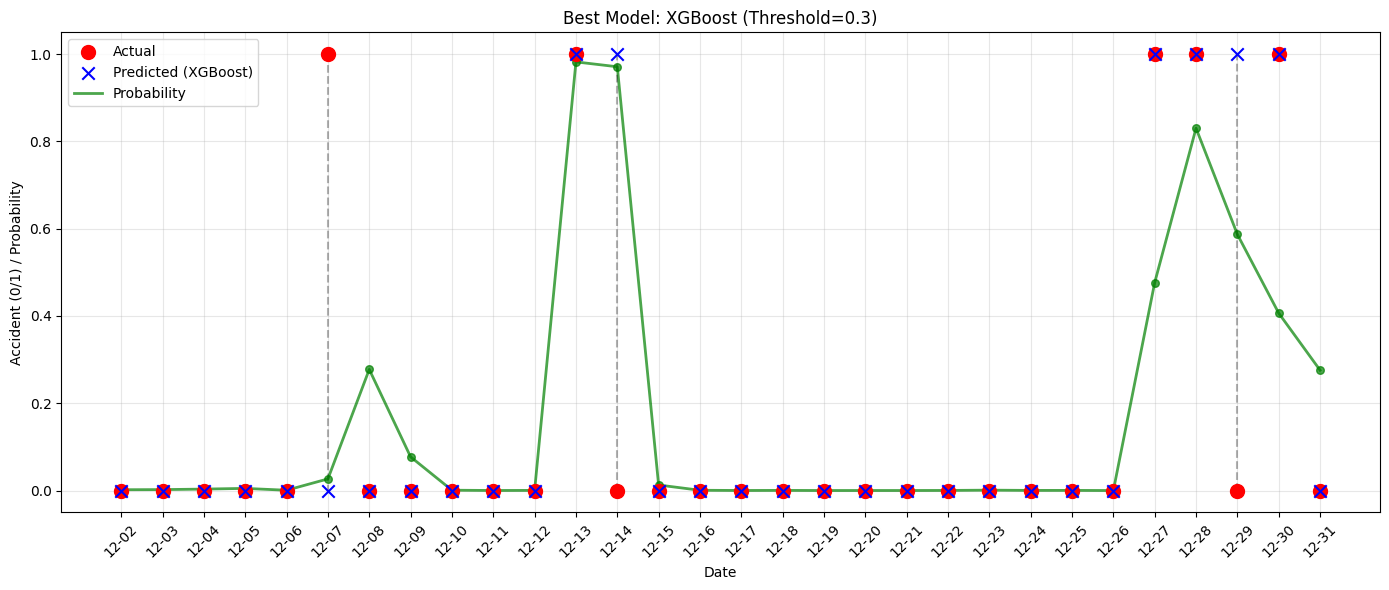

In [28]:
# ===============================
# Model Comparison: SARIMAX (with X) vs LightGBM vs XGBoost
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, f1_score, precision_score, recall_score
import lightgbm as lgb
import xgboost as xgb
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# Set random seed
np.random.seed(42)

# -------------------------------
# 1) Load & prepare data
# -------------------------------
df = pd.read_csv("clean_data-2023-2024.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
df["target"] = (df["เกิดเหตุ"] > 0).astype(int)

# Features for tree models (excluding datetime, target, and accident count)
features = [c for c in df.columns if c not in ["datetime", "เกิดเหตุ", "target"]]

# Split: last 30 days as test
train_full = df.iloc[:-30].copy()
test = df.iloc[-30:].copy()

print(f"Train size: {len(train_full)}, Test size: {len(test)}")

# -------------------------------
# 2) Monthly Mean & Std Visualization
# -------------------------------
df_monthly = df.copy()
df_monthly['month'] = df_monthly['datetime'].dt.to_period('M')
monthly_stats = df_monthly.groupby('month')['เกิดเหตุ'].agg(['mean', 'std']).reset_index()
monthly_stats['month'] = monthly_stats['month'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(monthly_stats['month'], monthly_stats['mean'], marker='o', color='blue')
plt.title('Monthly Mean of Accidents')
plt.xlabel('Month')
plt.ylabel('Mean')

plt.subplot(1, 2, 2)
plt.plot(monthly_stats['month'], monthly_stats['std'], marker='o', color='orange')
plt.title('Monthly Std of Accidents')
plt.xlabel('Month')
plt.ylabel('Std')

plt.tight_layout()
plt.show()

# -------------------------------
# 3) Helper: Evaluate function
# -------------------------------
def evaluate(y_true, y_pred, y_prob=None, model_name="", threshold_note=""):
    rmse = mean_squared_error(y_true, y_prob if y_prob is not None else y_pred, squared=False)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Threshold": threshold_note,
        "RMSE": rmse,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "y_pred": y_pred.copy(),
        "y_prob": y_prob.copy() if y_prob is not None else y_pred.copy()
    }

# -------------------------------
# 4) SARIMAX with Exogenous Variables (X) + Auto Order
# -------------------------------
print("\n🔍 Tuning SARIMAX with exogenous variables...")

# Endogenous: number of accidents
endog_train = train_full.set_index("datetime")["เกิดเหตุ"]
endog_test = test.set_index("datetime")["เกิดเหตุ"]

# Exogenous: all other features (traffic, day info)
exog_cols = features  # ได้แก่ รถน้อยกว่า4ล้อ, รถ4ล้อ, ..., is_holiday
exog_train = train_full.set_index("datetime")[exog_cols]
exog_test = test.set_index("datetime")[exog_cols]

# Check stationarity
def is_stationary(series):
    result = adfuller(series.dropna())
    return result[1] < 0.05

d = 0
ts_diff = endog_train.copy()
while not is_stationary(ts_diff) and d < 2:
    d += 1
    ts_diff = ts_diff.diff().dropna()

print(f"SARIMAX: Using d={d}")

# Grid search
best_aic = np.inf
best_order = None
best_seasonal_order = None

p_vals = range(0, 3)
q_vals = range(0, 3)
seasonal_periods = [7, 14, 30]

for s in seasonal_periods:
    for P in range(0, 2):
        for Q in range(0, 2):
            for p in p_vals:
                for q in q_vals:
                    try:
                        order = (p, d, q)
                        seasonal_order = (P, d, Q, s)
                        model = SARIMAX(
                            endog=endog_train,
                            exog=exog_train,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        fitted = model.fit(disp=False)
                        if fitted.aic < best_aic:
                            best_aic = fitted.aic
                            best_order = order
                            best_seasonal_order = seasonal_order
                    except:
                        continue

print(f"Best SARIMAX: order={best_order}, seasonal_order={best_seasonal_order}")

# Final model
sarimax_model = SARIMAX(
    endog=endog_train,
    exog=exog_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarimax_fitted = sarimax_model.fit(disp=False)

# Forecast
sarimax_pred = sarimax_fitted.forecast(steps=len(exog_test), exog=exog_test)
sarimax_pred_binary_05 = (sarimax_pred > 0.5).astype(int)
sarimax_pred_binary_03 = (sarimax_pred > 0.3).astype(int)

sarimax_results = {
    "0.5": evaluate(test["target"], sarimax_pred_binary_05, sarimax_pred, "SARIMAX", "0.5"),
    "0.3": evaluate(test["target"], sarimax_pred_binary_03, sarimax_pred, "SARIMAX", "0.3")
}

# -------------------------------
# 5) LightGBM with Auto Lag/Rolling
# -------------------------------
print("\n🔍 Tuning LightGBM...")

def create_lgb_features(df, lags, rollings):
    df_feat = df.copy()
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['target'].shift(lag)
    for win in rollings:
        df_feat[f'roll_mean_{win}'] = df_feat['target'].rolling(win).mean()
        df_feat[f'roll_std_{win}'] = df_feat['target'].rolling(win).std()
    return df_feat

candidate_windows = [1, 3, 7, 14, 30]
best_f1 = -1
best_lag = None
best_roll = None
best_lgb_pred_prob = None

for win in candidate_windows:
    lags = [win]
    rollings = [win]
    
    df_lgb = create_lgb_features(train_full, lags, rollings)
    df_lgb = df_lgb.dropna()
    if len(df_lgb) < 10:
        continue
        
    X_train = df_lgb.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_train = df_lgb["target"]
    
    model = lgb.LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    df_test_full = pd.concat([train_full.iloc[-max(candidate_windows):], test], ignore_index=True)
    df_test_feat = create_lgb_features(df_test_full, lags, rollings)
    df_test_final = df_test_feat.iloc[-len(test):].dropna()
    
    if len(df_test_final) != len(test):
        continue
        
    X_test = df_test_final.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(test["target"].iloc[:len(y_pred)], y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_lag = lags
        best_roll = rollings
        best_lgb_pred_prob = y_prob

print(f"Best LightGBM: lag={best_lag}, rolling={best_roll}, F1={best_f1:.4f}")

lgb_pred_binary_05 = (best_lgb_pred_prob > 0.5).astype(int)
lgb_pred_binary_03 = (best_lgb_pred_prob > 0.3).astype(int)

lgb_results = {
    "0.5": evaluate(test["target"], lgb_pred_binary_05, best_lgb_pred_prob, "LightGBM", "0.5"),
    "0.3": evaluate(test["target"], lgb_pred_binary_03, best_lgb_pred_prob, "LightGBM", "0.3")
}

# -------------------------------
# 6) XGBoost with Auto Lag/Rolling
# -------------------------------
print("\n🔍 Tuning XGBoost...")

best_f1_xgb = -1
best_lag_xgb = None
best_roll_xgb = None
best_xgb_pred_prob = None

for win in candidate_windows:
    lags = [win]
    rollings = [win]
    
    df_xgb = create_lgb_features(train_full, lags, rollings)  # reuse function
    df_xgb = df_xgb.dropna()
    if len(df_xgb) < 10:
        continue
        
    X_train = df_xgb.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_train = df_xgb["target"]
    
    # Scale for XGBoost (optional but helps)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        scale_pos_weight=sum(y_train == 0) / sum(y_train == 1),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_train_scaled, y_train)
    
    df_test_full = pd.concat([train_full.iloc[-max(candidate_windows):], test], ignore_index=True)
    df_test_feat = create_lgb_features(df_test_full, lags, rollings)
    df_test_final = df_test_feat.iloc[-len(test):].dropna()
    
    if len(df_test_final) != len(test):
        continue
        
    X_test = df_test_final.drop(columns=["datetime", "เกิดเหตุ", "target"])
    X_test_scaled = scaler.transform(X_test)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(test["target"].iloc[:len(y_pred)], y_pred)
    
    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_lag_xgb = lags
        best_roll_xgb = rollings
        best_xgb_pred_prob = y_prob

print(f"Best XGBoost: lag={best_lag_xgb}, rolling={best_roll_xgb}, F1={best_f1_xgb:.4f}")

xgb_pred_binary_05 = (best_xgb_pred_prob > 0.5).astype(int)
xgb_pred_binary_03 = (best_xgb_pred_prob > 0.3).astype(int)

xgb_results = {
    "0.5": evaluate(test["target"], xgb_pred_binary_05, best_xgb_pred_prob, "XGBoost", "0.5"),
    "0.3": evaluate(test["target"], xgb_pred_binary_03, best_xgb_pred_prob, "XGBoost", "0.3")
}

# -------------------------------
# 7) Compare All Results
# -------------------------------
all_results = []
for res in [sarimax_results, lgb_results, xgb_results]:
    for thresh in ["0.3", "0.5"]:
        all_results.append(res[thresh])

results_df = pd.DataFrame(all_results)
print("\n📊 Comparison Results:")
print(results_df[["Model", "Threshold", "RMSE", "F1", "Precision", "Recall"]].round(4))

# Find best model by F1
best_row = results_df.loc[results_df["F1"].idxmax()]
print(f"\n🏆 Best Model: {best_row['Model']} (Threshold={best_row['Threshold']}) with F1={best_row['F1']:.4f}")

# -------------------------------
# 8) Plot Best Model: Actual vs Predicted + Probability
# -------------------------------
dates = test["datetime"].dt.strftime("%m-%d")
y_true = test["target"]
y_pred = best_row["y_pred"]
y_prob = best_row["y_prob"]

plt.figure(figsize=(14,6))
x_pos = range(len(dates))

plt.scatter(x_pos, y_true, color="red", label="Actual", marker="o", s=100, zorder=5)
plt.scatter(x_pos, y_pred, color="blue", label=f"Predicted ({best_row['Model']})", marker="x", s=80, zorder=5)
plt.plot(x_pos, y_prob, color="green", linestyle="-", linewidth=2, alpha=0.7, label="Probability")
plt.scatter(x_pos, y_prob, color="green", s=30, alpha=0.7, zorder=4)

for i in range(len(dates)):
    plt.plot([x_pos[i], x_pos[i]], [y_true.iloc[i], y_pred[i]], 'k--', alpha=0.3)

plt.xticks(x_pos, dates, rotation=45)
plt.xlabel("Date")
plt.ylabel("Accident (0/1) / Probability")
plt.title(f"Best Model: {best_row['Model']} (Threshold={best_row['Threshold']})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

NameError: name 'best_xgb_model' is not defined

Using d = 0
🔍 Searching best p in [1, 2, 3, 7]
  p=1 → AIC=459.97
  p=2 → AIC=461.36
  p=3 → AIC=462.80
  p=7 → AIC=460.62

✅ Best p = 1 (AIC = 459.97)


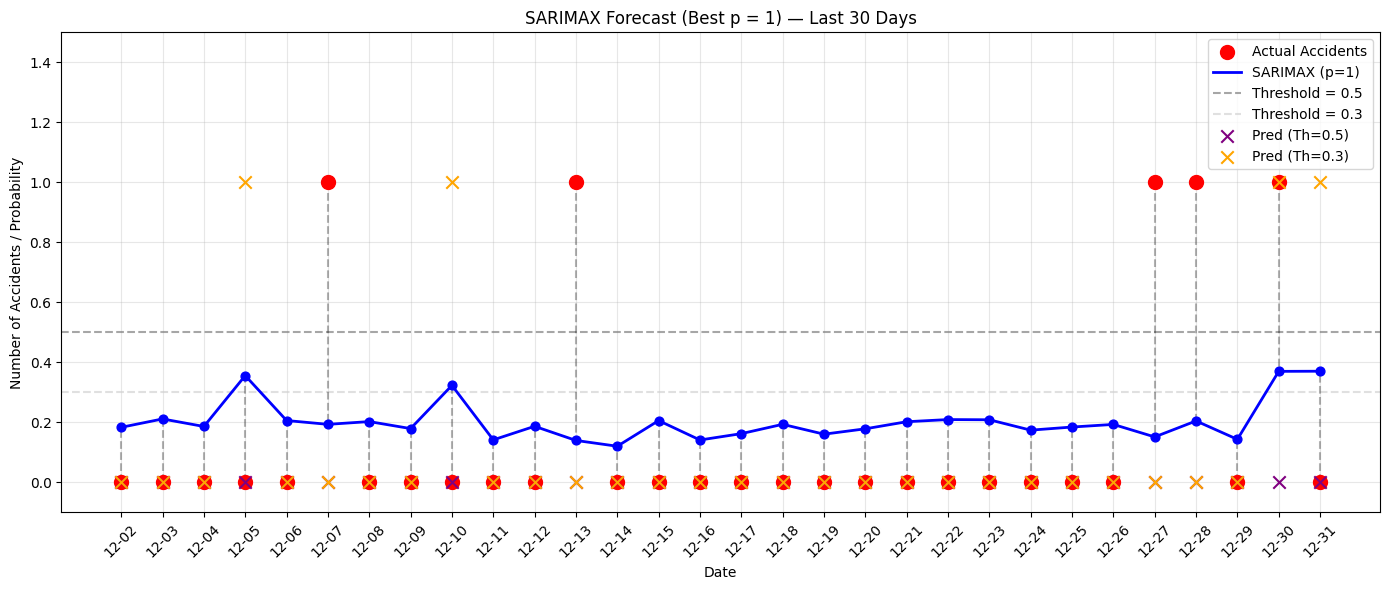


📊 Classification Metrics (Threshold = 0.5):
F1-score: 0.0000
Recall:   0.0000
Precision:0.0000

📊 Classification Metrics (Threshold = 0.3):
F1-score: 0.2222
Recall:   0.2000
Precision:0.2500


In [ ]:
# ===============================
# SARIMAX with Full Auto-Tuning (p, q, seasonality)
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings("ignore")

# -------------------------------
# 1) Load data
# -------------------------------
df = pd.read_csv("clean_data-2023-2024.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
train_full = df.iloc[:-30].copy()
test = df.iloc[-30:].copy()

# -------------------------------
# 2) Prepare endog & exog
# -------------------------------
endog_train = train_full.set_index("datetime")["เกิดเหตุ"]
endog_test = test.set_index("datetime")["เกิดเหตุ"]

exog_cols = ["รถน้อยกว่า4ล้อทั้งหมด", "รถ4ล้อทั้งหมด", "รถมากกว่า4ล้อทั้งหมด", "day_of_week", "is_weekend", "is_holiday"]
exog_train = train_full.set_index("datetime")[exog_cols]
exog_test = test.set_index("datetime")[exog_cols]

# -------------------------------
# 3) Determine differencing order (d)
# -------------------------------
def is_stationary(series):
    result = adfuller(series.dropna())
    return result[1] < 0.05

d = 0
ts_diff = endog_train.copy()
while not is_stationary(ts_diff) and d < 2:
    d += 1
    ts_diff = ts_diff.diff().dropna()

print(f"Using d = {d}")

# -------------------------------
# 4) Full grid search: (p, q) + seasonal (P, Q, m)
# -------------------------------
# Non-seasonal
p_vals = [0, 1, 2, 3, 7]
q_vals = [0, 1, 2]

# Seasonal
seasonal_periods = [1, 3, 7, 14, 30]  # m values
P_vals = [0, 1]
Q_vals = [0, 1]

best_aic = np.inf
best_order = None
best_seasonal_order = None
best_fitted = None

print("🔍 Starting full SARIMAX grid search...")
total_combinations = len(p_vals) * len(q_vals) * len(seasonal_periods) * len(P_vals) * len(Q_vals)
count = 0

for p in p_vals:
    for q in q_vals:
        for m in seasonal_periods:
            for P in P_vals:
                for Q in Q_vals:
                    count += 1
                    try:
                        order = (p, d, q)
                        seasonal_order = (P, d, Q, m)
                        model = SARIMAX(
                            endog=endog_train,
                            exog=exog_train,
                            order=order,
                            seasonal_order=seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False
                        )
                        fitted = model.fit(disp=False)
                        if fitted.aic < best_aic:
                            best_aic = fitted.aic
                            best_order = order
                            best_seasonal_order = seasonal_order
                            best_fitted = fitted
                        if count % 20 == 0:
                            print(f"  Tried {count}/{total_combinations} combinations...")
                    except Exception as e:
                        continue

print(f"\n✅ Best SARIMAX found:")
print(f"   Order: {best_order}")
print(f"   Seasonal Order: {best_seasonal_order}")
print(f"   AIC: {best_aic:.2f}")

# -------------------------------
# 5) Forecast
# -------------------------------
sarimax_pred = best_fitted.forecast(steps=len(exog_test), exog=exog_test)
sarimax_pred_binary_05 = (sarimax_pred > 0.5).astype(int)
sarimax_pred_binary_03 = (sarimax_pred > 0.3).astype(int)

# -------------------------------
# 6) Plot Results
# -------------------------------
dates = test["datetime"].dt.strftime("%m-%d")
actual = test["เกิดเหตุ"].values
x_pos = range(len(dates))

plt.figure(figsize=(14, 6))

# Actual
plt.scatter(x_pos, actual, color="red", label="Actual Accidents", marker="o", s=100, zorder=5)

# Forecast
plt.plot(x_pos, sarimax_pred, color="blue", linewidth=2, label="SARIMAX Forecast", zorder=4)
plt.scatter(x_pos, sarimax_pred, color="blue", s=40, zorder=4)

# Thresholds
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label="Threshold = 0.5")
plt.axhline(y=0.3, color='lightgray', linestyle='--', alpha=0.7, label="Threshold = 0.3")

# Binary predictions
plt.scatter(x_pos, sarimax_pred_binary_05, color="purple", marker="x", s=80, label="Pred (Th=0.5)", zorder=5)
plt.scatter(x_pos, sarimax_pred_binary_03, color="orange", marker="x", s=80, label="Pred (Th=0.3)", zorder=5)

# Connect lines
for i in range(len(dates)):
    plt.plot([x_pos[i], x_pos[i]], [actual[i], sarimax_pred[i]], 'k--', alpha=0.3)

plt.xticks(x_pos, dates, rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of Accidents / Probability")
plt.title("SARIMAX Forecast (Auto-Tuned) — Last 30 Days")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-0.1, max(actual.max(), sarimax_pred.max()) + 0.5)
plt.tight_layout()
plt.show()

# -------------------------------
# 7) Evaluation Metrics
# -------------------------------
from sklearn.metrics import f1_score, recall_score, precision_score

y_true_binary = (test["เกิดเหตุ"] > 0).astype(int)

print("\n📊 Classification Metrics (Threshold = 0.5):")
print(f"F1-score: {f1_score(y_true_binary, sarimax_pred_binary_05):.4f}")
print(f"Recall:   {recall_score(y_true_binary, sarimax_pred_binary_05):.4f}")
print(f"Precision:{precision_score(y_true_binary, sarimax_pred_binary_05):.4f}")

print("\n📊 Classification Metrics (Threshold = 0.3):")
print(f"F1-score: {f1_score(y_true_binary, sarimax_pred_binary_03):.4f}")
print(f"Recall:   {recall_score(y_true_binary, sarimax_pred_binary_03):.4f}")
print(f"Precision:{precision_score(y_true_binary, sarimax_pred_binary_03):.4f}")

Train size: 701, Test size: 30

🔍 Tuning LightGBM...
Best LightGBM: lag=[3], rolling=[3], F1=0.6000

🔍 Tuning XGBoost...
Best XGBoost: lag=[3], rolling=[3], F1=0.4444

📊 Comparison Results:
      Model Threshold    RMSE      F1  Precision  Recall
0  LightGBM       0.3  0.3372  0.6154     0.5000     0.8
1  LightGBM       0.5  0.3372  0.6000     0.6000     0.6
2   XGBoost       0.3  0.3188  0.7273     0.6667     0.8
3   XGBoost       0.5  0.3188  0.4444     0.5000     0.4


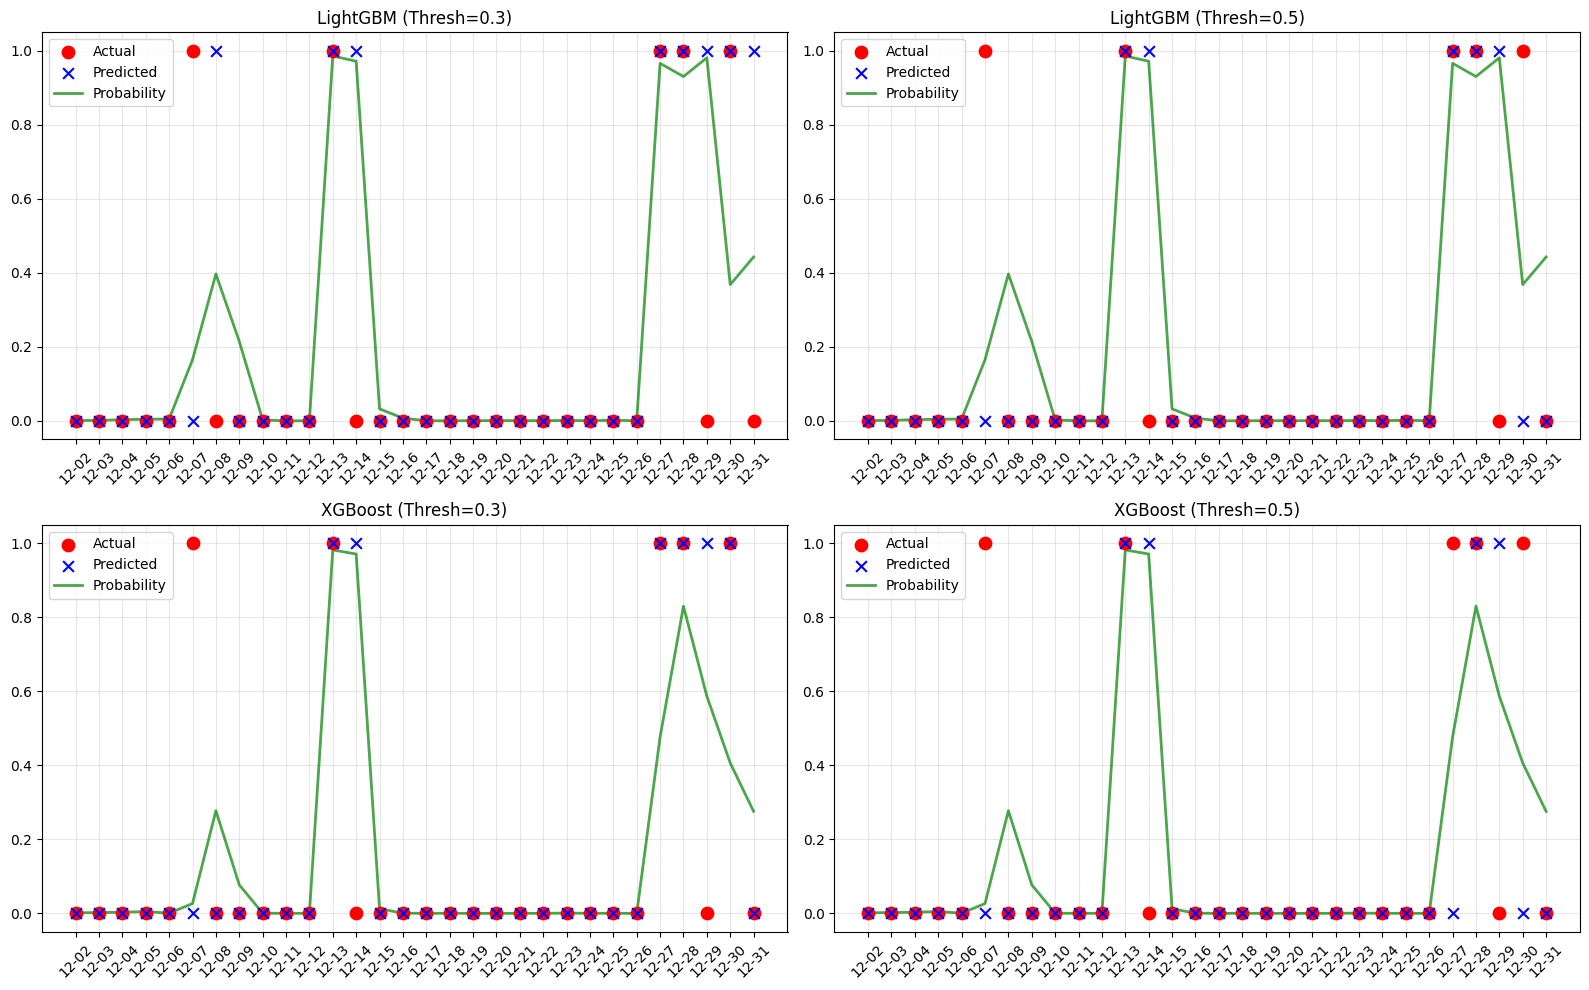


💾 Models saved to 'saved_models/'


In [ ]:
# ===============================
# Model Comparison: LightGBM vs XGBoost (save models + plot all)
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, f1_score, precision_score, recall_score
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Set random seed
np.random.seed(42)

# -------------------------------
# 1) Load & prepare data
# -------------------------------
df = pd.read_csv("clean_data-2023-2024.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
df["target"] = (df["เกิดเหตุ"] > 0).astype(int)

features = [c for c in df.columns if c not in ["datetime", "เกิดเหตุ", "target"]]

# Split: last 30 days as test
train_full = df.iloc[:-30].copy()
test = df.iloc[-30:].copy()

print(f"Train size: {len(train_full)}, Test size: {len(test)}")

# -------------------------------
# 2) Evaluate function
# -------------------------------
def evaluate(y_true, y_pred, y_prob=None, model_name="", threshold_note=""):
    rmse = mean_squared_error(y_true, y_prob if y_prob is not None else y_pred, squared=False)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Threshold": threshold_note,
        "RMSE": rmse,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "y_pred": y_pred.copy(),
        "y_prob": y_prob.copy() if y_prob is not None else y_pred.copy()
    }

# -------------------------------
# 3) Helper: Lag & Rolling features
# -------------------------------
def create_lgb_features(df, lags, rollings):
    df_feat = df.copy()
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['target'].shift(lag)
    for win in rollings:
        df_feat[f'roll_mean_{win}'] = df_feat['target'].rolling(win).mean()
        df_feat[f'roll_std_{win}'] = df_feat['target'].rolling(win).std()
    return df_feat

candidate_windows = [1, 3, 7, 14, 30]

# -------------------------------
# 4) LightGBM
# -------------------------------
print("\n🔍 Tuning LightGBM...")

best_f1 = -1
best_lag = None
best_roll = None
best_lgb_pred_prob = None
best_lgb_model = None

for win in candidate_windows:
    lags = [win]
    rollings = [win]
    
    df_lgb = create_lgb_features(train_full, lags, rollings).dropna()
    if len(df_lgb) < 10:
        continue
        
    X_train = df_lgb.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_train = df_lgb["target"]
    
    model = lgb.LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    df_test_full = pd.concat([train_full.iloc[-max(candidate_windows):], test], ignore_index=True)
    df_test_feat = create_lgb_features(df_test_full, lags, rollings)
    df_test_final = df_test_feat.iloc[-len(test):].dropna()
    
    if len(df_test_final) != len(test):
        continue
        
    X_test = df_test_final.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(test["target"].iloc[:len(y_pred)], y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_lag = lags
        best_roll = rollings
        best_lgb_pred_prob = y_prob
        best_lgb_model = model

print(f"Best LightGBM: lag={best_lag}, rolling={best_roll}, F1={best_f1:.4f}")

lgb_pred_binary_05 = (best_lgb_pred_prob > 0.5).astype(int)
lgb_pred_binary_03 = (best_lgb_pred_prob > 0.3).astype(int)

lgb_results = {
    "0.5": evaluate(test["target"], lgb_pred_binary_05, best_lgb_pred_prob, "LightGBM", "0.5"),
    "0.3": evaluate(test["target"], lgb_pred_binary_03, best_lgb_pred_prob, "LightGBM", "0.3")
}

# -------------------------------
# 5) XGBoost
# -------------------------------
print("\n🔍 Tuning XGBoost...")

best_f1_xgb = -1
best_lag_xgb = None
best_roll_xgb = None
best_xgb_pred_prob = None
best_xgb_model = None
best_xgb_scaler = None

for win in candidate_windows:
    lags = [win]
    rollings = [win]
    
    df_xgb = create_lgb_features(train_full, lags, rollings).dropna()
    if len(df_xgb) < 10:
        continue
        
    X_train = df_xgb.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_train = df_xgb["target"]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        scale_pos_weight=sum(y_train == 0) / sum(y_train == 1),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_train_scaled, y_train)
    
    df_test_full = pd.concat([train_full.iloc[-max(candidate_windows):], test], ignore_index=True)
    df_test_feat = create_lgb_features(df_test_full, lags, rollings)
    df_test_final = df_test_feat.iloc[-len(test):].dropna()
    
    if len(df_test_final) != len(test):
        continue
        
    X_test = df_test_final.drop(columns=["datetime", "เกิดเหตุ", "target"])
    X_test_scaled = scaler.transform(X_test)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(test["target"].iloc[:len(y_pred)], y_pred)
    
    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_lag_xgb = lags
        best_roll_xgb = rollings
        best_xgb_pred_prob = y_prob
        best_xgb_model = model
        best_xgb_scaler = scaler

print(f"Best XGBoost: lag={best_lag_xgb}, rolling={best_roll_xgb}, F1={best_f1_xgb:.4f}")

xgb_pred_binary_05 = (best_xgb_pred_prob > 0.5).astype(int)
xgb_pred_binary_03 = (best_xgb_pred_prob > 0.3).astype(int)

xgb_results = {
    "0.5": evaluate(test["target"], xgb_pred_binary_05, best_xgb_pred_prob, "XGBoost", "0.5"),
    "0.3": evaluate(test["target"], xgb_pred_binary_03, best_xgb_pred_prob, "XGBoost", "0.3")
}

# -------------------------------
# 6) Compare All Results
# -------------------------------
all_results = []
for res in [lgb_results, xgb_results]:
    for thresh in ["0.3", "0.5"]:
        all_results.append(res[thresh])

results_df = pd.DataFrame(all_results)
print("\n📊 Comparison Results:")
print(results_df[["Model", "Threshold", "RMSE", "F1", "Precision", "Recall"]].round(4))

# -------------------------------
# 7) Plot All Models
# -------------------------------
dates = test["datetime"].dt.strftime("%m-%d")
y_true = test["target"]

plt.figure(figsize=(16, 10))

for idx, row in results_df.iterrows():
    plt.subplot(2, 2, idx+1)
    y_pred = row["y_pred"]
    y_prob = row["y_prob"]
    model_name = row["Model"]
    thresh = row["Threshold"]

    x_pos = range(len(dates))
    plt.scatter(x_pos, y_true, color="red", label="Actual", marker="o", s=80, zorder=5)
    plt.scatter(x_pos, y_pred, color="blue", label="Predicted", marker="x", s=60, zorder=5)
    plt.plot(x_pos, y_prob, color="green", linestyle="-", linewidth=2, alpha=0.7, label="Probability")

    plt.xticks(x_pos, dates, rotation=45)
    plt.ylim(-0.05, 1.05)
    plt.title(f"{model_name} (Thresh={thresh})")
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------
# 8) Save Models
# -------------------------------
os.makedirs("saved_models", exist_ok=True)
joblib.dump(best_lgb_model, "saved_models/lightgbm_model.pkl")
joblib.dump(best_xgb_model, "saved_models/xgboost_model.pkl")
joblib.dump(best_xgb_scaler, "saved_models/xgb_scaler.pkl")
print("\n💾 Models saved to 'saved_models/'")


Train size: 701, Test size: 30

🔍 Tuning LightGBM...
Best LightGBM: lag=[3], rolling=[3], F1=0.4615

🔍 Tuning XGBoost...
Best XGBoost: lag=[14], rolling=[14], F1=0.5000

📊 Comparison Results:
      Model Threshold    RMSE      F1  Precision  Recall
0  LightGBM       0.3  0.3699  0.4615     0.3750     0.6
1  LightGBM       0.5  0.3699  0.4615     0.3750     0.6
2   XGBoost       0.3  0.3950  0.3077     0.2500     0.4
3   XGBoost       0.5  0.3950  0.5000     0.6667     0.4


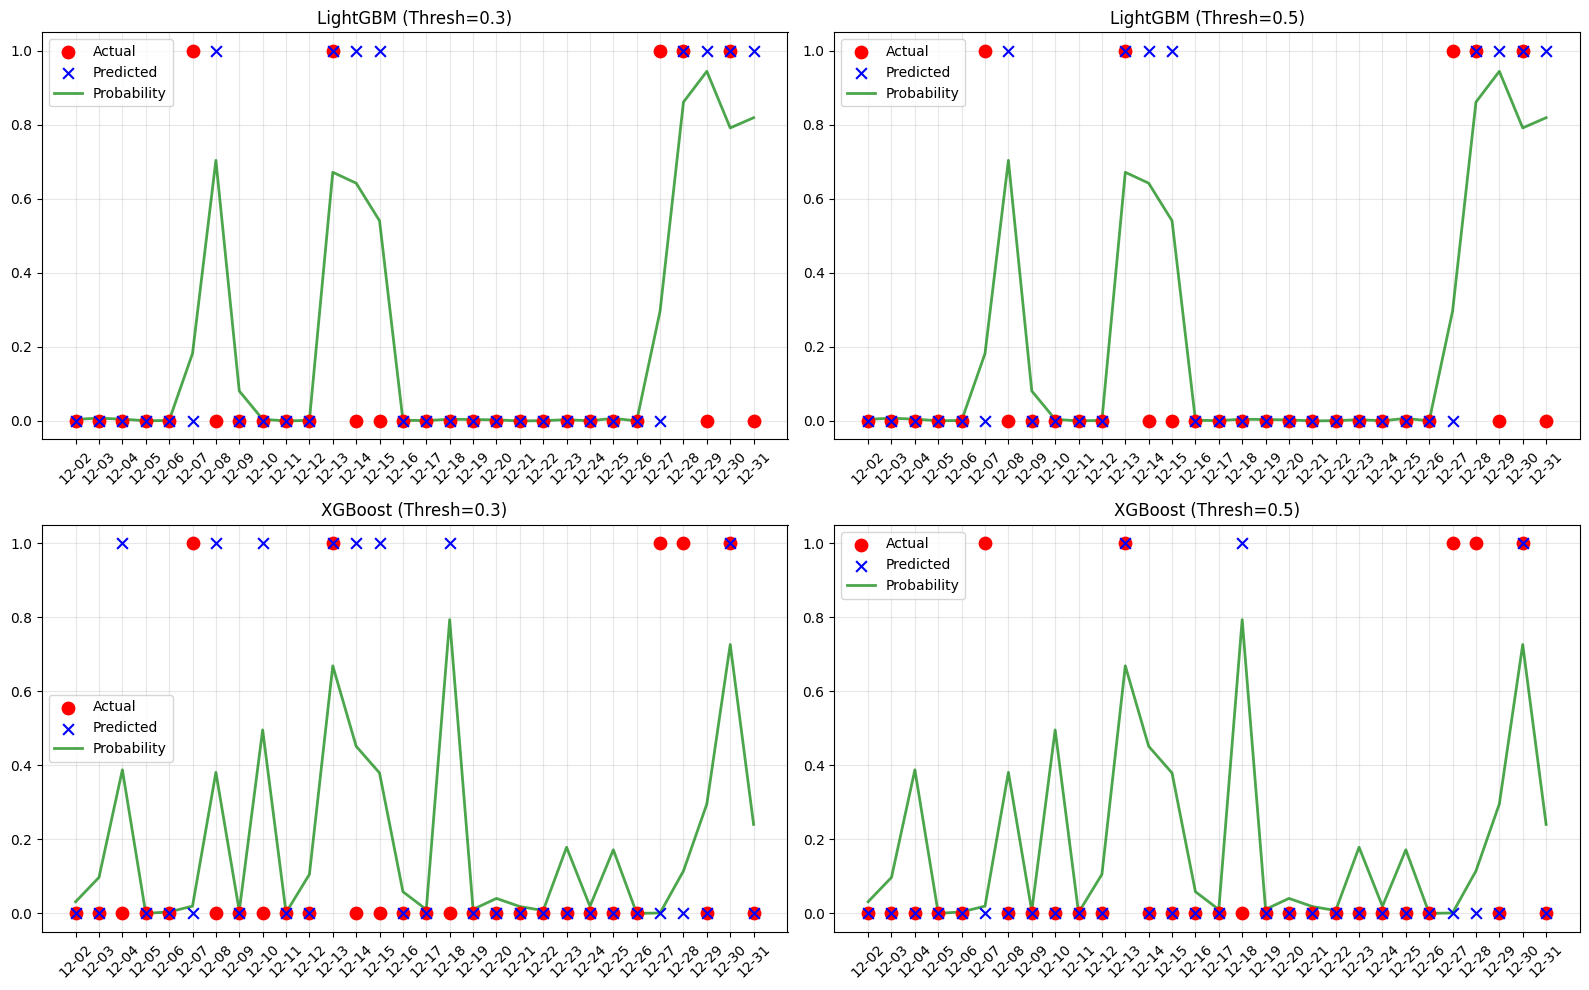


💾 Models saved to 'saved_models/'


In [3]:
# ===============================
# Model Comparison: LightGBM vs XGBoost (save models + plot all)
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, f1_score, precision_score, recall_score
import lightgbm as lgb
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# Set random seed
np.random.seed(42)

# -------------------------------
# 1) Load & prepare data
# -------------------------------
df = pd.read_csv("clean_data_no_weather-2023-2024.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
df["target"] = (df["เกิดเหตุ"] > 0).astype(int)

features = [c for c in df.columns if c not in ["datetime", "เกิดเหตุ", "target"]]

# Split: last 30 days as test
train_full = df.iloc[:-30].copy()
test = df.iloc[-30:].copy()

print(f"Train size: {len(train_full)}, Test size: {len(test)}")

# -------------------------------
# 2) Evaluate function
# -------------------------------
def evaluate(y_true, y_pred, y_prob=None, model_name="", threshold_note=""):
    rmse = mean_squared_error(y_true, y_prob if y_prob is not None else y_pred, squared=False)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    return {
        "Model": model_name,
        "Threshold": threshold_note,
        "RMSE": rmse,
        "F1": f1,
        "Precision": prec,
        "Recall": rec,
        "y_pred": y_pred.copy(),
        "y_prob": y_prob.copy() if y_prob is not None else y_pred.copy()
    }

# -------------------------------
# 3) Helper: Lag & Rolling features
# -------------------------------
def create_lgb_features(df, lags, rollings):
    df_feat = df.copy()
    for lag in lags:
        df_feat[f'lag_{lag}'] = df_feat['target'].shift(lag)
    for win in rollings:
        df_feat[f'roll_mean_{win}'] = df_feat['target'].rolling(win).mean()
        df_feat[f'roll_std_{win}'] = df_feat['target'].rolling(win).std()
    return df_feat

candidate_windows = [1, 3, 7, 14, 30]

# -------------------------------
# 4) LightGBM
# -------------------------------
print("\n🔍 Tuning LightGBM...")

best_f1 = -1
best_lag = None
best_roll = None
best_lgb_pred_prob = None
best_lgb_model = None

for win in candidate_windows:
    lags = [win]
    rollings = [win]
    
    df_lgb = create_lgb_features(train_full, lags, rollings).dropna()
    if len(df_lgb) < 10:
        continue
        
    X_train = df_lgb.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_train = df_lgb["target"]
    
    model = lgb.LGBMClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    
    df_test_full = pd.concat([train_full.iloc[-max(candidate_windows):], test], ignore_index=True)
    df_test_feat = create_lgb_features(df_test_full, lags, rollings)
    df_test_final = df_test_feat.iloc[-len(test):].dropna()
    
    if len(df_test_final) != len(test):
        continue
        
    X_test = df_test_final.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(test["target"].iloc[:len(y_pred)], y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_lag = lags
        best_roll = rollings
        best_lgb_pred_prob = y_prob
        best_lgb_model = model

print(f"Best LightGBM: lag={best_lag}, rolling={best_roll}, F1={best_f1:.4f}")

lgb_pred_binary_05 = (best_lgb_pred_prob > 0.5).astype(int)
lgb_pred_binary_03 = (best_lgb_pred_prob > 0.3).astype(int)

lgb_results = {
    "0.5": evaluate(test["target"], lgb_pred_binary_05, best_lgb_pred_prob, "LightGBM", "0.5"),
    "0.3": evaluate(test["target"], lgb_pred_binary_03, best_lgb_pred_prob, "LightGBM", "0.3")
}

# -------------------------------
# 5) XGBoost
# -------------------------------
print("\n🔍 Tuning XGBoost...")

best_f1_xgb = -1
best_lag_xgb = None
best_roll_xgb = None
best_xgb_pred_prob = None
best_xgb_model = None
best_xgb_scaler = None

for win in candidate_windows:
    lags = [win]
    rollings = [win]
    
    df_xgb = create_lgb_features(train_full, lags, rollings).dropna()
    if len(df_xgb) < 10:
        continue
        
    X_train = df_xgb.drop(columns=["datetime", "เกิดเหตุ", "target"])
    y_train = df_xgb["target"]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    model = xgb.XGBClassifier(
        n_estimators=100,
        scale_pos_weight=sum(y_train == 0) / sum(y_train == 1),
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_train_scaled, y_train)
    
    df_test_full = pd.concat([train_full.iloc[-max(candidate_windows):], test], ignore_index=True)
    df_test_feat = create_lgb_features(df_test_full, lags, rollings)
    df_test_final = df_test_feat.iloc[-len(test):].dropna()
    
    if len(df_test_final) != len(test):
        continue
        
    X_test = df_test_final.drop(columns=["datetime", "เกิดเหตุ", "target"])
    X_test_scaled = scaler.transform(X_test)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    y_pred = (y_prob > 0.5).astype(int)
    f1 = f1_score(test["target"].iloc[:len(y_pred)], y_pred)
    
    if f1 > best_f1_xgb:
        best_f1_xgb = f1
        best_lag_xgb = lags
        best_roll_xgb = rollings
        best_xgb_pred_prob = y_prob
        best_xgb_model = model
        best_xgb_scaler = scaler

print(f"Best XGBoost: lag={best_lag_xgb}, rolling={best_roll_xgb}, F1={best_f1_xgb:.4f}")

xgb_pred_binary_05 = (best_xgb_pred_prob > 0.5).astype(int)
xgb_pred_binary_03 = (best_xgb_pred_prob > 0.3).astype(int)

xgb_results = {
    "0.5": evaluate(test["target"], xgb_pred_binary_05, best_xgb_pred_prob, "XGBoost", "0.5"),
    "0.3": evaluate(test["target"], xgb_pred_binary_03, best_xgb_pred_prob, "XGBoost", "0.3")
}

# -------------------------------
# 6) Compare All Results
# -------------------------------
all_results = []
for res in [lgb_results, xgb_results]:
    for thresh in ["0.3", "0.5"]:
        all_results.append(res[thresh])

results_df = pd.DataFrame(all_results)
print("\n📊 Comparison Results:")
print(results_df[["Model", "Threshold", "RMSE", "F1", "Precision", "Recall"]].round(4))

# -------------------------------
# 7) Plot All Models
# -------------------------------
dates = test["datetime"].dt.strftime("%m-%d")
y_true = test["target"]

plt.figure(figsize=(16, 10))

for idx, row in results_df.iterrows():
    plt.subplot(2, 2, idx+1)
    y_pred = row["y_pred"]
    y_prob = row["y_prob"]
    model_name = row["Model"]
    thresh = row["Threshold"]

    x_pos = range(len(dates))
    plt.scatter(x_pos, y_true, color="red", label="Actual", marker="o", s=80, zorder=5)
    plt.scatter(x_pos, y_pred, color="blue", label="Predicted", marker="x", s=60, zorder=5)
    plt.plot(x_pos, y_prob, color="green", linestyle="-", linewidth=2, alpha=0.7, label="Probability")

    plt.xticks(x_pos, dates, rotation=45)
    plt.ylim(-0.05, 1.05)
    plt.title(f"{model_name} (Thresh={thresh})")
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------
# 8) Save Models
# -------------------------------
os.makedirs("saved_models", exist_ok=True)
joblib.dump(best_lgb_model, "saved_models/lightgbm_model.pkl")
joblib.dump(best_xgb_model, "saved_models/xgboost_model.pkl")
joblib.dump(best_xgb_scaler, "saved_models/xgb_scaler.pkl")
print("\n💾 Models saved to 'saved_models/'")


In [15]:
import pandas as pd
import numpy as np

# โหลดข้อมูลพยากรณ์
df = pd.read_csv("forecast_2025_full_with_weather.csv", parse_dates=["datetime"])
df = df.set_index("datetime")

# สมมติว่าไม่มีอุบัติเหตุในปี 2025 (หรือยังไม่รู้ → ใช้ 0)
df["target"] = 0

# สร้าง lag และ rolling features
lags = [1, 3, 7, 14, 30]
rollings = [1, 3, 7, 14, 30]

for lag in lags:
    df[f"lag_{lag}"] = df["target"].shift(lag)

for win in rollings:
    df[f"roll_mean_{win}"] = df["target"].rolling(window=win, min_periods=1).mean()
    df[f"roll_std_{win}"] = df["target"].rolling(window=win, min_periods=1).std().fillna(0)

# จัดเรียงคอลัมน์ตามที่คุณต้องการ
cols_order = [
    "datetime",
    "temperature_F", "humidity_%", "pressure_in",
    "รถน้อยกว่า4ล้อทั้งหมด", "รถ4ล้อทั้งหมด", "รถมากกว่า4ล้อทั้งหมด",
    "target"
]
for lag in lags:
    cols_order.append(f"lag_{lag}")
for win in rollings:
    cols_order.extend([f"roll_mean_{win}", f"roll_std_{win}"])

# แปลงกลับเป็น datetime column
df = df.reset_index()

# เรียงคอลัมน์
df_final = df[cols_order]

# บันทึกไฟล์
df_final.to_csv("forecast_2025_features.csv", index=False)
print("✅ สร้างไฟล์ forecast_2025_features.csv เรียบร้อย!")

✅ สร้างไฟล์ forecast_2025_features.csv เรียบร้อย!


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import numpy as np

# -------------------------------
# 1. โหลดข้อมูลพยากรณ์ 2025 (ที่คุณมี)
# -------------------------------
df = pd.read_csv("forecast_2025_full_with_weather.csv", parse_dates=["datetime"])
df = df.set_index("datetime")

# กรองเฉพาะเดือนสิงหาคม 2025
df_aug = df.loc["2025-08-01":"2025-08-31"].copy().reset_index()

# สร้าง feature วัน
df_aug["day_of_week"] = df_aug["datetime"].dt.dayofweek  # 0=Mon, 6=Sun
df_aug["is_weekend"] = (df_aug["day_of_week"] >= 5).astype(int)
df_aug["is_holiday"] = 0  # ปรับเองตามปฏิทินไทยถ้ามีวันหยุด

# -------------------------------
# 2. เตรียม X ให้ตรงกับตอน train (9 features)
# -------------------------------
feature_cols = [
    'temperature_F',
    'humidity_%',
    'pressure_in',
    'รถน้อยกว่า4ล้อทั้งหมด',
    'รถ4ล้อทั้งหมด',
    'รถมากกว่า4ล้อทั้งหมด',
    'is_holiday',
    'day_of_week',
    'is_weekend'
]

X = df_aug[feature_cols].copy()
dates = df_aug["datetime"]

# -------------------------------
# 3. โหลดโมเดลและ scaler
# -------------------------------
lgb_model = joblib.load("saved_models/lightgbm_model.pkl")
xgb_model = joblib.load("saved_models/xgboost_model.pkl")
xgb_scaler = joblib.load("saved_models/xgb_scaler.pkl")

# -------------------------------
# 4. Predict
# -------------------------------
# LightGBM (ไม่ต้อง scale)
lgb_prob = lgb_model.predict_proba(X)[:, 1]
lgb_pred = (lgb_prob > 0.5).astype(int)

# XGBoost (ต้อง scale)
X_scaled = xgb_scaler.transform(X)
xgb_prob = xgb_model.predict_proba(X_scaled)[:, 1]
xgb_pred = (xgb_prob > 0.5).astype(int)

# -------------------------------
# 5. Plot
# -------------------------------
plt.figure(figsize=(16, 8))

# LightGBM
plt.subplot(2, 1, 1)
plt.plot(range(len(dates)), lgb_prob, color="blue", alpha=0.7, label="Accident Probability")
plt.scatter(range(len(dates)), lgb_pred, color="red", marker="x", s=60, label="Predicted Accident")
plt.title("LightGBM: Accident Prediction for August 2025")
plt.xticks(range(len(dates)), dates.dt.strftime("%d-%m"), rotation=45)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(alpha=0.3)

# XGBoost
plt.subplot(2, 1, 2)
plt.plot(range(len(dates)), xgb_prob, color="green", alpha=0.7, label="Accident Probability")
plt.scatter(range(len(dates)), xgb_pred, color="red", marker="x", s=60, label="Predicted Accident")
plt.title("XGBoost: Accident Prediction for August 2025")
plt.xticks(range(len(dates)), dates.dt.strftime("%d-%m"), rotation=45)
plt.ylim(-0.1, 1.1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("aug2025_accident_prediction_final.png", dpi=150)
plt.show()

# -------------------------------
# 6. บันทึกผลลัพธ์
# -------------------------------
result = pd.DataFrame({
    "วันที่": dates,
    "LGB_Prob": lgb_prob,
    "LGB_Pred": lgb_pred,
    "XGB_Prob": xgb_prob,
    "XGB_Pred": xgb_pred
})

result.to_csv("aug2025_accident_forecast_final.csv", index=False)
print("✅ ทำนายอุบัติเหตุสิงหาคม 2025 เสร็จสิ้น และบันทึกผลแล้ว!")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- humidity_%
- pressure_in
- temperature_F
Feature names seen at fit time, yet now missing:
- lag_14
- roll_mean_14
- roll_std_14


In [2]:
import pandas as pd

# อ่านไฟล์ CSV
df = pd.read_csv('clean_data-2023-2024.csv')

# ลบคอลัมน์สภาพอากาศ
columns_to_drop = ['temperature_F', 'humidity_%', 'pressure_in']
df_clean = df.drop(columns=columns_to_drop)

# บันทึกไฟล์ใหม่ (หรือทับไฟล์เดิมก็ได้)
df_clean.to_csv('clean_data_no_weather-2023-2024.csv', index=False)

print("ลบข้อมูลสภาพอากาศเรียบร้อยแล้ว!")

ลบข้อมูลสภาพอากาศเรียบร้อยแล้ว!


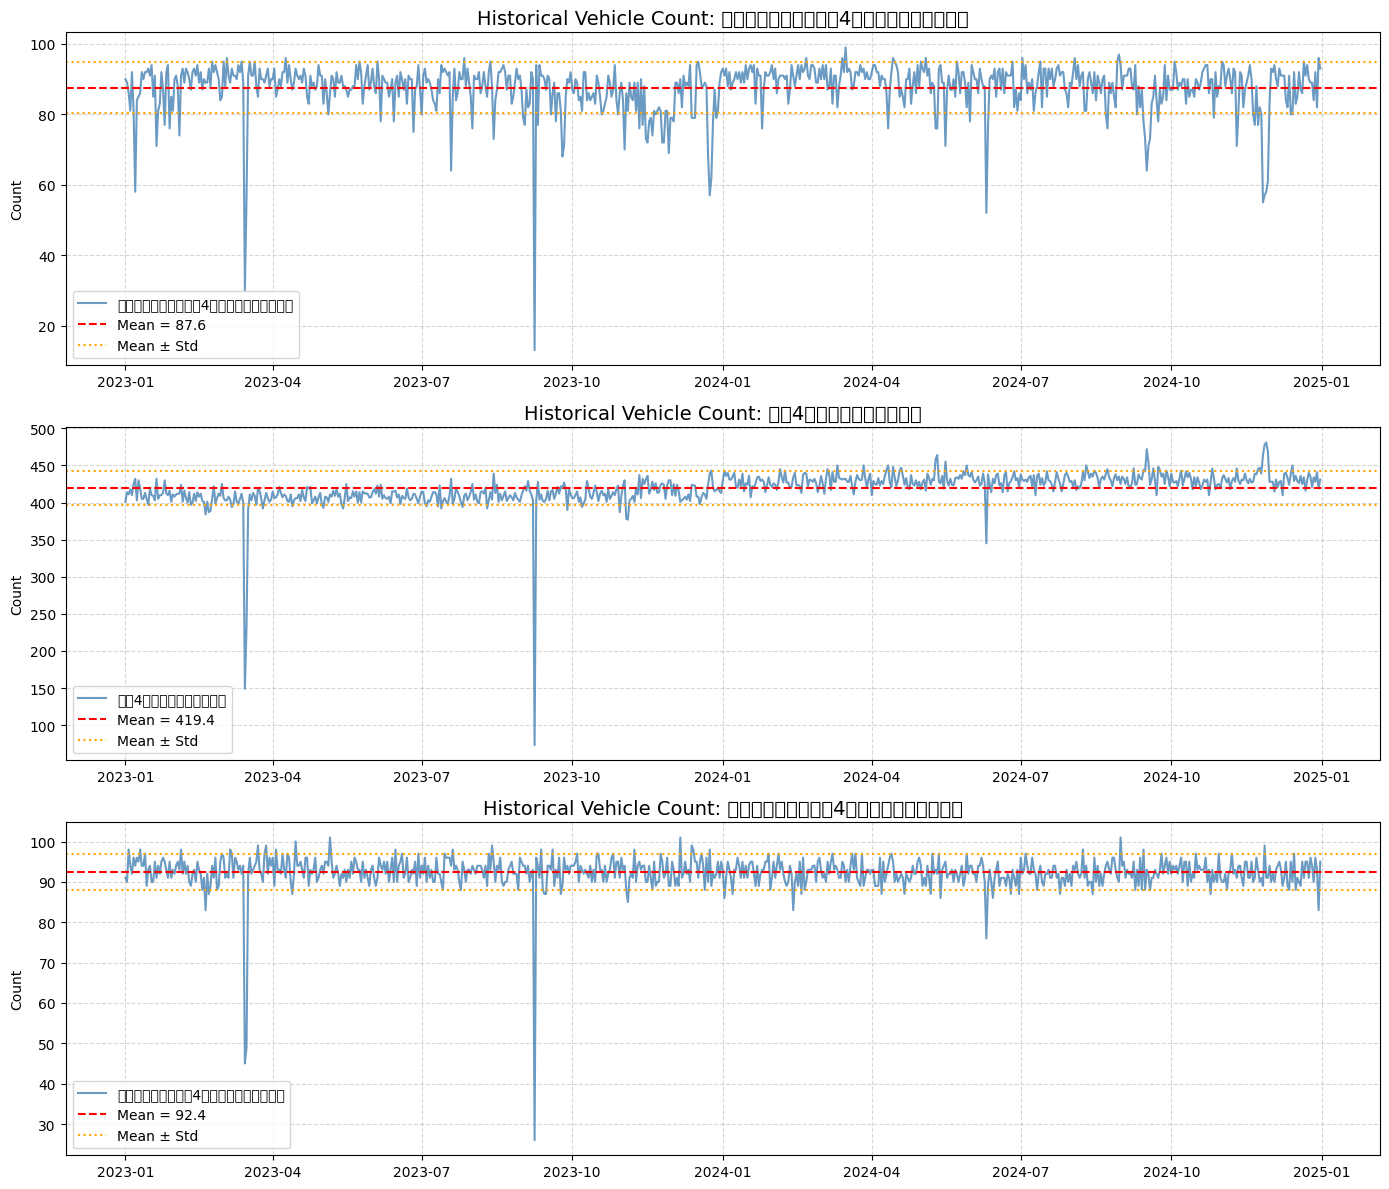


🚀 Forecasting: รถน้อยกว่า4ล้อทั้งหมด


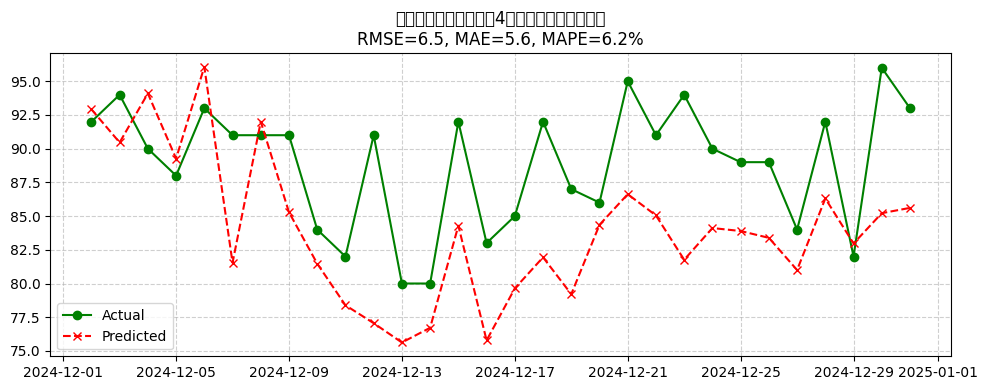

✅ RMSE: 6.52 | MAE: 5.59 | MAPE: 6.21%

🚀 Forecasting: รถ4ล้อทั้งหมด


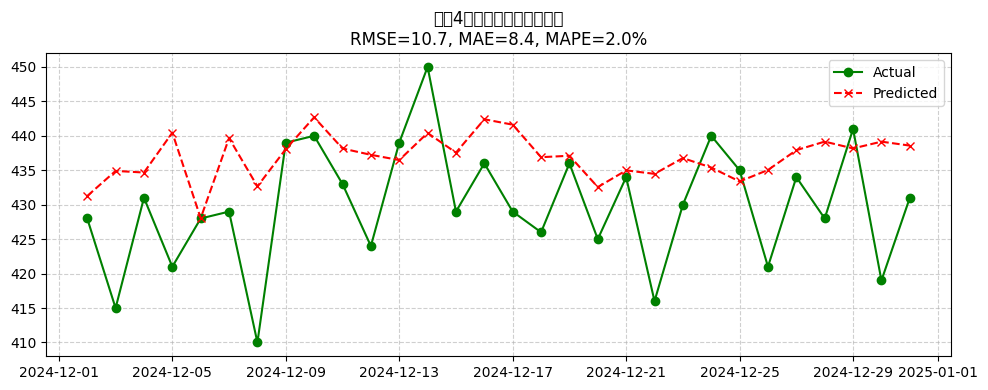

✅ RMSE: 10.65 | MAE: 8.44 | MAPE: 1.99%

🚀 Forecasting: รถมากกว่า4ล้อทั้งหมด


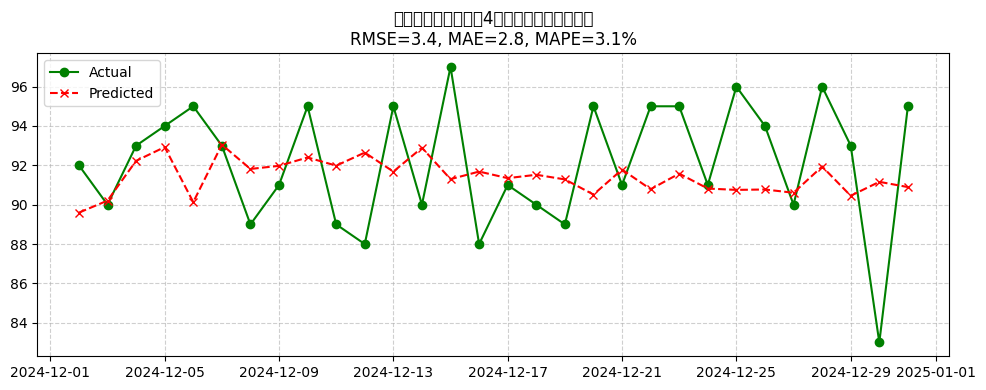

✅ RMSE: 3.39 | MAE: 2.81 | MAPE: 3.05%

📊 Model Performance (Last 30 Days):
                            RMSE       MAE  MAPE (%)
รถน้อยกว่า4ล้อทั้งหมด   6.516193  5.586896  6.213885
รถ4ล้อทั้งหมด          10.654083  8.435168  1.986861
รถมากกว่า4ล้อทั้งหมด    3.393652  2.806254  3.050830

📁 บันทึกผลพยากรณ์ปี 2025 ครบ 365 วัน (1 ม.ค. – 31 ธ.ค.) แล้ว!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# 1. โหลดข้อมูล
# ----------------------------
df = pd.read_csv('clean_data-2023-2024.csv', parse_dates=['datetime'])
df = df.set_index('datetime').asfreq('D')
df = df.fillna(method='ffill')

# ใช้เฉพาะ X ที่ต้องการ
target_cols = ['รถน้อยกว่า4ล้อทั้งหมด', 'รถ4ล้อทั้งหมด', 'รถมากกว่า4ล้อทั้งหมด']
exog_cols = ['temperature_F', 'humidity_%', 'pressure_in', 'is_holiday']  # ✅ ไม่รวม day_of_week, is_weekend

# ----------------------------
# 2. Visualization: ข้อมูลรถ + mean/std
# ----------------------------
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
for i, col in enumerate(target_cols):
    ax = axes[i]
    series = df[col]
    mean_val = series.mean()
    std_val = series.std()
    
    ax.plot(series, label=col, alpha=0.8, color='steelblue')
    ax.axhline(mean_val, color='red', linestyle='--', label=f'Mean = {mean_val:.1f}')
    ax.axhline(mean_val + std_val, color='orange', linestyle=':', label='Mean ± Std')
    ax.axhline(mean_val - std_val, color='orange', linestyle=':')
    
    ax.set_title(f'Historical Vehicle Count: {col}', fontsize=14)
    ax.set_ylabel('Count')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('vehicle_trends_with_mean_std.png', dpi=150)
plt.show()

# ----------------------------
# 3. ฟังก์ชันพยากรณ์ SARIMAX
# ----------------------------
def sarimax_forecast(target_col, exog_cols, df):
    y = df[target_col]
    X = df[exog_cols]
    
    n_test = 30
    y_train, y_test = y[:-n_test], y[-n_test:]
    X_train, X_test = X[:-n_test], X[-n_test:]
    
    # ฝึกโมเดล
    model = SARIMAX(
        endog=y_train,
        exog=X_train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)
    
    # ทำนายช่วง test
    y_pred_test = fitted.forecast(steps=n_test, exog=X_test)
    
    # คำนวณ metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae = mean_absolute_error(y_test, y_pred_test)
    mape = np.mean(np.abs((y_test - y_pred_test) / (y_test + 1e-8))) * 100  # +eps ป้องกัน division by zero
    
    # ----------------------------
    # สร้าง future exog สำหรับปี 2025: 1 ม.ค. - 31 ธ.ค. 2025 (365 วัน)
    # ----------------------------
    future_index = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')  # ✅ ครบ 365 วัน
    
    # ใช้ค่าเฉลี่ยรายวัน (month-day) จากข้อมูลปี 2023-2024
    df_exog = df[exog_cols].copy()
    df_exog['month_day'] = df_exog.index.strftime('%m-%d')
    daily_avg = df_exog.groupby('month_day').mean()
    
    future_exog = pd.DataFrame(index=future_index)
    future_exog['month_day'] = future_exog.index.strftime('%m-%d')
    future_exog = future_exog.merge(daily_avg, left_on='month_day', right_index=True, how='left')
    future_exog = future_exog.drop(columns=['month_day'])
    
    # เติมค่าที่อาจหาย (เช่น 29 ก.พ. ถ้าไม่มีในข้อมูล)
    future_exog = future_exog.fillna(method='ffill').fillna(method='bfill')
    
    # ทำนายปี 2025
    y_forecast_2025 = fitted.forecast(steps=len(future_index), exog=future_exog)
    
    # พล็อต Actual vs Predicted
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.index, y_test, 'o-', label='Actual', color='green')
    plt.plot(y_test.index, y_pred_test, 'x--', label='Predicted', color='red')
    plt.title(f'{target_col}\nRMSE={rmse:.1f}, MAE={mae:.1f}, MAPE={mape:.1f}%')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'actual_vs_pred_{target_col.replace(" ", "_")}.png', dpi=150)
    plt.show()
    
    return y_forecast_2025, rmse, mae, mape

# ----------------------------
# 4. รันทั้ง 3 ประเภทรถ
# ----------------------------
forecasts = {}
metrics = {}

for col in target_cols:
    print(f"\n🚀 Forecasting: {col}")
    forecast, rmse, mae, mape = sarimax_forecast(col, exog_cols, df)
    forecasts[col] = forecast
    metrics[col] = {'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape}
    print(f"✅ RMSE: {rmse:.2f} | MAE: {mae:.2f} | MAPE: {mape:.2f}%")

# แสดงตาราง metrics
metrics_df = pd.DataFrame(metrics).T
print("\n📊 Model Performance (Last 30 Days):")
print(metrics_df)

# ----------------------------
# 5. บันทึกผลลัพธ์ปี 2025 (1 ม.ค. - 31 ธ.ค.)
# ----------------------------
result_df = pd.DataFrame(forecasts)
result_df.index.name = 'datetime'
result_df.to_csv('forecast_2025_vehicle_counts.csv')
print("\n📁 บันทึกผลพยากรณ์ปี 2025 ครบ 365 วัน (1 ม.ค. – 31 ธ.ค.) แล้ว!")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# 1. โหลดข้อมูลดิบ
# ----------------------------
df = pd.read_csv('clean_data-2023-2024.csv', parse_dates=['datetime'])
df = df.set_index('datetime').asfreq('D')
df = df.fillna(method='ffill')

# ----------------------------
# 2. กำหนดช่วงเวลาปี 2025 ให้ชัดเจน: 1 ม.ค. - 31 ธ.ค. 2025 (365 วัน)
# ----------------------------
future_index = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
print(f"📅 สร้างช่วงเวลา 2025: {len(future_index)} วัน (จาก {future_index[0]} ถึง {future_index[-1]})")

# ----------------------------
# 3. พยากรณ์สภาพอากาศด้วย SARIMA
# ----------------------------
weather_cols = ['temperature_F', 'humidity_%', 'pressure_in']
weather_forecasts = {}

for col in weather_cols:
    print(f"🌦️ พยากรณ์ {col}...")
    y = df[col]
    model = SARIMAX(
        y,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(future_index))
    weather_forecasts[col] = forecast

# ----------------------------
# 4. พยากรณ์จำนวนรถด้วย SARIMAX (ในช่วงเวลาเดียวกัน!)
# ----------------------------
vehicle_cols = ['รถน้อยกว่า4ล้อทั้งหมด', 'รถ4ล้อทั้งหมด', 'รถมากกว่า4ล้อทั้งหมด']
exog_cols = ['temperature_F', 'humidity_%', 'pressure_in', 'is_holiday']  # X features

vehicle_forecasts = {}

# สร้าง future_exog สำหรับปี 2025 (ใช้ค่าเฉลี่ยรายวันจากอดีต)
df_exog = df[exog_cols].copy()
df_exog['month_day'] = df_exog.index.strftime('%m-%d')
daily_avg = df_exog.groupby('month_day').mean()

future_exog = pd.DataFrame(index=future_index)
future_exog['month_day'] = future_exog.index.strftime('%m-%d')
future_exog = future_exog.merge(daily_avg, left_on='month_day', right_index=True, how='left')
future_exog = future_exog.drop(columns=['month_day'])
future_exog = future_exog.fillna(method='ffill').fillna(method='bfill')

# พยากรณ์แต่ละประเภทรถ
for col in vehicle_cols:
    print(f"🚗 พยากรณ์ {col}...")
    y = df[col]
    X = df[exog_cols]
    
    model = SARIMAX(
        y,
        exog=X,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)
    forecast = fitted.forecast(steps=len(future_index), exog=future_exog)
    vehicle_forecasts[col] = forecast

# ----------------------------
# 5. รวมทุกอย่างใน DataFrame เดียว
# ----------------------------
final_df = pd.DataFrame(index=future_index)
# เพิ่มสภาพอากาศ
for col in weather_cols:
    final_df[col] = weather_forecasts[col]
# เพิ่มจำนวนรถ
for col in vehicle_cols:
    final_df[col] = vehicle_forecasts[col]

final_df.index.name = 'datetime'

# บันทึกไฟล์
final_df.to_csv('forecast_2025_full_with_weather.csv')
print("\n✅ บันทึกไฟล์สุดท้ายแล้ว: forecast_2025_full_with_weather.csv")
print("\nตัวอย่างข้อมูล:")
print(final_df.head())

📅 สร้างช่วงเวลา 2025: 365 วัน (จาก 2025-01-01 00:00:00 ถึง 2025-12-31 00:00:00)
🌦️ พยากรณ์ temperature_F...
🌦️ พยากรณ์ humidity_%...
🌦️ พยากรณ์ pressure_in...
🚗 พยากรณ์ รถน้อยกว่า4ล้อทั้งหมด...
🚗 พยากรณ์ รถ4ล้อทั้งหมด...
🚗 พยากรณ์ รถมากกว่า4ล้อทั้งหมด...

✅ บันทึกไฟล์สุดท้ายแล้ว: forecast_2025_full_with_weather.csv

ตัวอย่างข้อมูล:
            temperature_F  humidity_%  pressure_in  รถน้อยกว่า4ล้อทั้งหมด  \
datetime                                                                    
2025-01-01      79.659379   82.649137    29.753933              88.042867   
2025-01-02      79.568078   83.727873    29.747631              85.767439   
2025-01-03      79.966759   83.217944    29.741303              88.263680   
2025-01-04      80.369704   83.199507    29.733672              86.157347   
2025-01-05      80.120209   83.604643    29.729222              90.948922   

            รถ4ล้อทั้งหมด  รถมากกว่า4ล้อทั้งหมด  
datetime                                         
2025-01-01     431.843834 

In [1]:
# ============================================
# ⚙️ 1. Install dependencies (run once)
# ============================================
# !pip install pytorch-lightning pytorch-forecasting pandas matplotlib scikit-learn torchmetrics torch

# ============================================
# 📦 2. Import library
# ============================================
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from pytorch_lightning import Trainer
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# ============================================
# 📂 3. Load dataset
# ============================================
df = pd.read_csv("clean_data-2023-2024.csv", parse_dates=["datetime"])
df = df.sort_values("datetime")
df["series_id"] = "accident_rate"

print(f"Data range: {df['datetime'].min().date()} → {df['datetime'].max().date()}")

# ============================================
# 📅 4. Split data
# ============================================
# แยกเดือนสุดท้ายไว้เป็น test
last_month = df["datetime"].max().month
last_year = df["datetime"].max().year

test_df = df[(df["datetime"].dt.year == last_year) & (df["datetime"].dt.month == last_month)]
train_val_df = df[~df.index.isin(test_df.index)]

print(f"Train/Val: {train_val_df.shape[0]} rows, Test (last month): {test_df.shape[0]} rows")

# ============================================
# ⚖️ 5. Handle class imbalance
# ============================================
classes = np.unique(train_val_df["เกิดเหตุ"])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_val_df["เกิดเหตุ"])
class_weights = torch.tensor(weights, dtype=torch.float)
print("Class Weights:", class_weights)

# ============================================
# 🧮 6. สร้าง TimeSeriesDataSet
# ============================================
max_encoder_length = 30   # ใช้ข้อมูลย้อนหลัง 30 วัน
max_prediction_length = 1 # พยากรณ์วันถัดไป

training_cutoff = train_val_df["datetime"].max() - pd.Timedelta(days=60)  # ใช้ 2 เดือนสุดท้ายของ train_val เป็น validation

training = TimeSeriesDataSet(
    train_val_df[train_val_df.datetime <= training_cutoff],
    time_idx="datetime",
    target="เกิดเหตุ",
    group_ids=["series_id"],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=["temperature_F", "humidity_%", "pressure_in",
                              "รถน้อยกว่า4ล้อทั้งหมด", "รถ4ล้อทั้งหมด", "รถมากกว่า4ล้อทั้งหมด",
                              "day_of_week", "is_weekend", "is_holiday"],
    time_varying_unknown_reals=[],
    target_normalizer=None,  # binary classification
    add_relative_time_idx=True,
    add_target_scales=False,
)

validation = TimeSeriesDataSet.from_dataset(training, train_val_df[train_val_df.datetime > training_cutoff])
test_dataset = TimeSeriesDataSet.from_dataset(training, test_df, stop_randomization=True)

# dataloaders
batch_size = 64
train_loader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
test_loader = test_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

# ============================================
# 🤖 7. Define TFT model
# ============================================
# ใช้ BCEWithLogitsLoss (รองรับ class imbalance ผ่าน pos_weight)
loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=class_weights[1].unsqueeze(0))

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.2,
    hidden_continuous_size=16,
    output_size=1,
    loss=loss_fn,
    log_interval=10,
    reduce_on_plateau_patience=3,
)

# ============================================
# 🚀 8. Train the model
# ============================================
trainer = Trainer(max_epochs=20, accelerator="auto", enable_checkpointing=True)
trainer.fit(tft, train_loader, val_loader)

# ============================================
# 🔍 9. Evaluate on test set (เดือนสุดท้าย)
# ============================================
# คำนวณค่า prediction
predictions = tft.predict(test_loader, mode="prediction").numpy().flatten()
y_true = np.concatenate([y[0].numpy() for x, y in iter(test_loader)])
y_pred_class = (predictions > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(y_true, y_pred_class))
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_class))

# ============================================
# 📊 10. Plot Actual vs Predicted Probability
# ============================================
plot_df = test_df.copy()
plot_df["pred_prob"] = predictions
plot_df = plot_df.sort_values("datetime")

plt.figure(figsize=(10,5))
plt.plot(plot_df["datetime"], plot_df["pred_prob"], label="Predicted Probability", color="orange", linewidth=2)
plt.scatter(plot_df["datetime"], plot_df["เกิดเหตุ"], label="Actual (0=No Accident, 1=Accident)", color="blue", alpha=0.7)
plt.title("Actual vs Predicted Probability (Last Month)")
plt.xlabel("Date")
plt.ylabel("Accident Probability")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Data range: 2023-01-01 → 2024-12-31
Train/Val: 700 rows, Test (last month): 31 rows
Class Weights: tensor([  0.2941,   1.8617,  17.5000, 175.0000])


AssertionError: Timeseries index should be of type integer

In [2]:
import torch
import pytorch_lightning as pl
import pytorch_forecasting as pf

print("Torch:", torch.__version__)
print("PyTorch-Lightning:", pl.__version__)
print("PyTorch-Forecasting:", pf.__version__)

Torch: 2.8.0+cpu
PyTorch-Lightning: 1.9.5
PyTorch-Forecasting: 1.4.0


In [3]:
import pytorch_forecasting as pf
print(pf.__version__)  # ต้องได้ '0.10.3'

1.4.0
